# Water Quality Descriptive Statistics
This notebook provides descriptive statistics and visualizations for the water quality data in `data/water_quality.csv` using Seaborn.

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set aesthetic style for Seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Load the data
file_path = 'data/water_quality.csv'
df = pd.read_csv(file_path)

# Display the first few rows
df.head()

,Sr. No,Date of data collection,Time of data collection,pond_id,region,Type,Is follow up,Is follow up possible,Reason follow up not possible,Group,...,Self-initiated corrective actions taken,Self-initiated corrective actions implemented on (exact date),Self-initiated corrective actions implemented (date range),Self-initiated corrective actions notes,Feed amount (kg),Stocking density (per acre),Species,Weight,Notes,Have fish been helped
0,12335,01/27/2026,16:05,pond_5f07dc7a,Eluru,Evening,No,NaN,NaN,Regular ara pond,...,NaN,NaN,NaN,NaN,NaN,4190.0,"Rohu (Labeo rohita), Catla (Catla catla)",100.0,NaN,No
1,12329,01/27/2026,15:53,pond_0c63298a,Eluru,Evening,No,NaN,NaN,Regular ara pond,...,NaN,NaN,NaN,NaN,NaN,1556.0,"Catla (Catla catla), Rohu (Labeo rohita)",NaN,NaN,No
2,12334,01/27/2026,15:50,pond_44865e41,Eluru,Evening,No,NaN,NaN,Regular ara pond,...,NaN,NaN,NaN,NaN,NaN,20000.0,"Rohu (Labeo rohita), Catla (Catla catla)",30.0,NaN,No
3,12328,01/27/2026,15:47,pond_8dd26bbf,Eluru,Evening,No,NaN,NaN,Regular ara pond,...,NaN,NaN,NaN,NaN,NaN,2182.0,"Catla (Catla catla), Rohu (Labeo rohita)",NaN,NaN,No
4,12327,01/27/2026,15:42,pond_e78b9c9a,Eluru,Evening,No,NaN,NaN,Regular ara pond,...,NaN,NaN,NaN,NaN,NaN,8046.0,"Catla (Catla catla), Rohu (Labeo rohita)",NaN,NaN,No


In [12]:
# Deciles of daily unique pond counts by region using all observations

region_col = 'region' if 'region' in df.columns else None
if region_col is None:
    raise KeyError("Expected a 'region' column in data/water_quality.csv")

all_obs = df.copy()
all_obs['date'] = pd.to_datetime(all_obs['Date of data collection'], format='%m/%d/%Y')
all_obs['region'] = all_obs[region_col].astype(str).str.lower()

regions = ['nellore', 'eluru']
daily_region_counts = (
    all_obs[all_obs['region'].isin(regions)]
    .groupby([all_obs['date'].dt.normalize(), 'region'])['pond_id']
    .nunique()
    .rename('unique_ponds')
    .reset_index()
)
daily_region_counts.columns = ['date', 'region', 'unique_ponds']

rows = []
for region in regions:
    region_daily = daily_region_counts[daily_region_counts['region'] == region]['unique_ponds']
    if region_daily.empty:
        continue
    deciles = region_daily.quantile([i / 10 for i in range(1, 10)]).round(1)
    rows.extend(
        {
            'region': region.title(),
            'decile': f'P{int(q * 100)}',
            'unique_ponds_per_day': value,
        }
        for q, value in deciles.items()
    )

decile_df_all = pd.DataFrame(rows)
decile_df_all

,region,decile,unique_ponds_per_day
0,Nellore,P10,1.0
1,Nellore,P20,2.0
2,Nellore,P30,2.0
3,Nellore,P40,3.0
4,Nellore,P50,3.0
5,Nellore,P60,3.0
6,Nellore,P70,4.0
7,Nellore,P80,4.0
8,Nellore,P90,5.0
9,Eluru,P10,2.0


## Data Overview and Cleaning

In [8]:
# Selecting numeric columns for analysis
numeric_cols = [
    'DO (mg/L)', 'pH', 'Temp (in °C)', 
    'Ammonia—TAN (NH3-N) (mg/L)', 'Ammonia—NH3 (mg/L)',
    'Feed amount (kg)', 'Stocking density (per acre)', 'Weight'
]

# Binary flag for correlation analysis only: Morning = 1, Not morning = 0
df['is_morning'] = df['Type'].astype(str).str.lower().eq('morning').astype(int)

# Convert columns to numeric, handling errors
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Basic summary statistics
df[numeric_cols].describe()

,DO (mg/L),pH,Temp (in °C),Ammonia—TAN (NH3-N) (mg/L),Ammonia—NH3 (mg/L),Feed amount (kg),Stocking density (per acre),Weight
count,11416.000000,11416.000000,11413.000000,5564.000000,841.000000,6209.000000,8781.000000,4881.000000
mean,6.554774,8.193809,29.524665,0.166797,0.015470,486.461266,8161.438333,536.387625
std,3.465116,0.281936,2.589333,0.200130,0.021343,550.520258,20864.423349,353.185339
min,0.000000,5.520000,21.400000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.500000,8.020000,27.700000,0.030000,0.000000,60.000000,2324.000000,250.000000
50%,4.700000,8.220000,29.700000,0.120000,0.010000,260.000000,2907.000000,500.000000
75%,9.700000,8.390000,31.300000,0.250000,0.020000,750.000000,4706.000000,800.000000
max,27.100000,9.780000,37.900000,3.000000,0.200000,3300.000000,235294.000000,2000.000000


## Visualizing Distributions
We'll use Seaborn's `histplot` to see the distribution of key parameters.

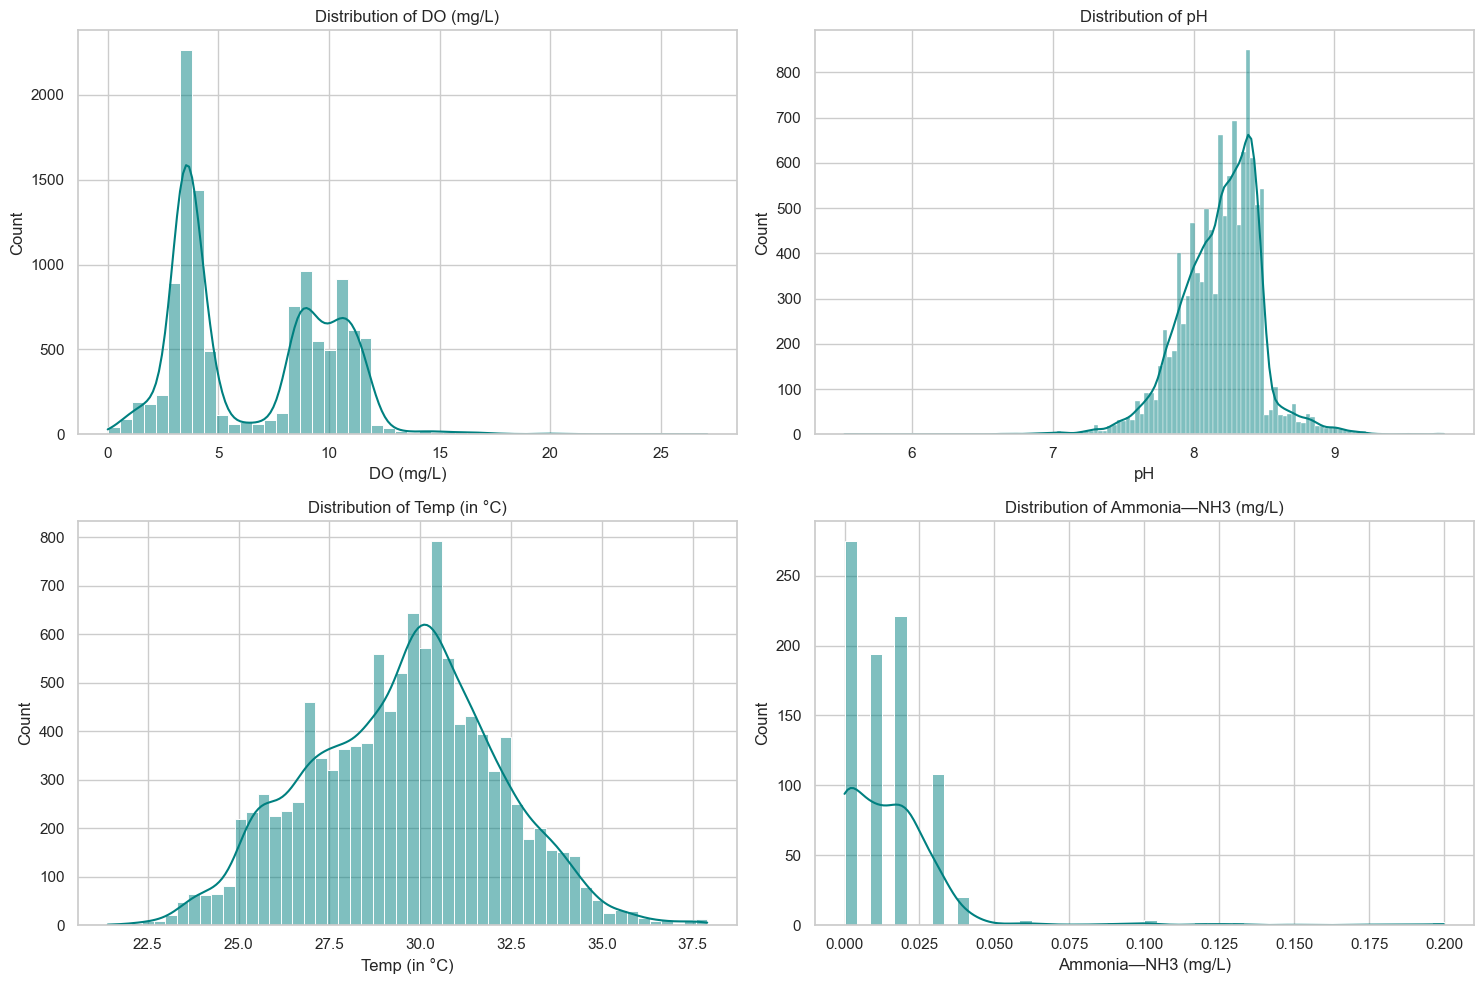

In [3]:
plt.figure(figsize=(15, 10))

cols_to_plot = ['DO (mg/L)', 'pH', 'Temp (in °C)', 'Ammonia—NH3 (mg/L)']
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col].dropna(), kde=True, color='teal')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

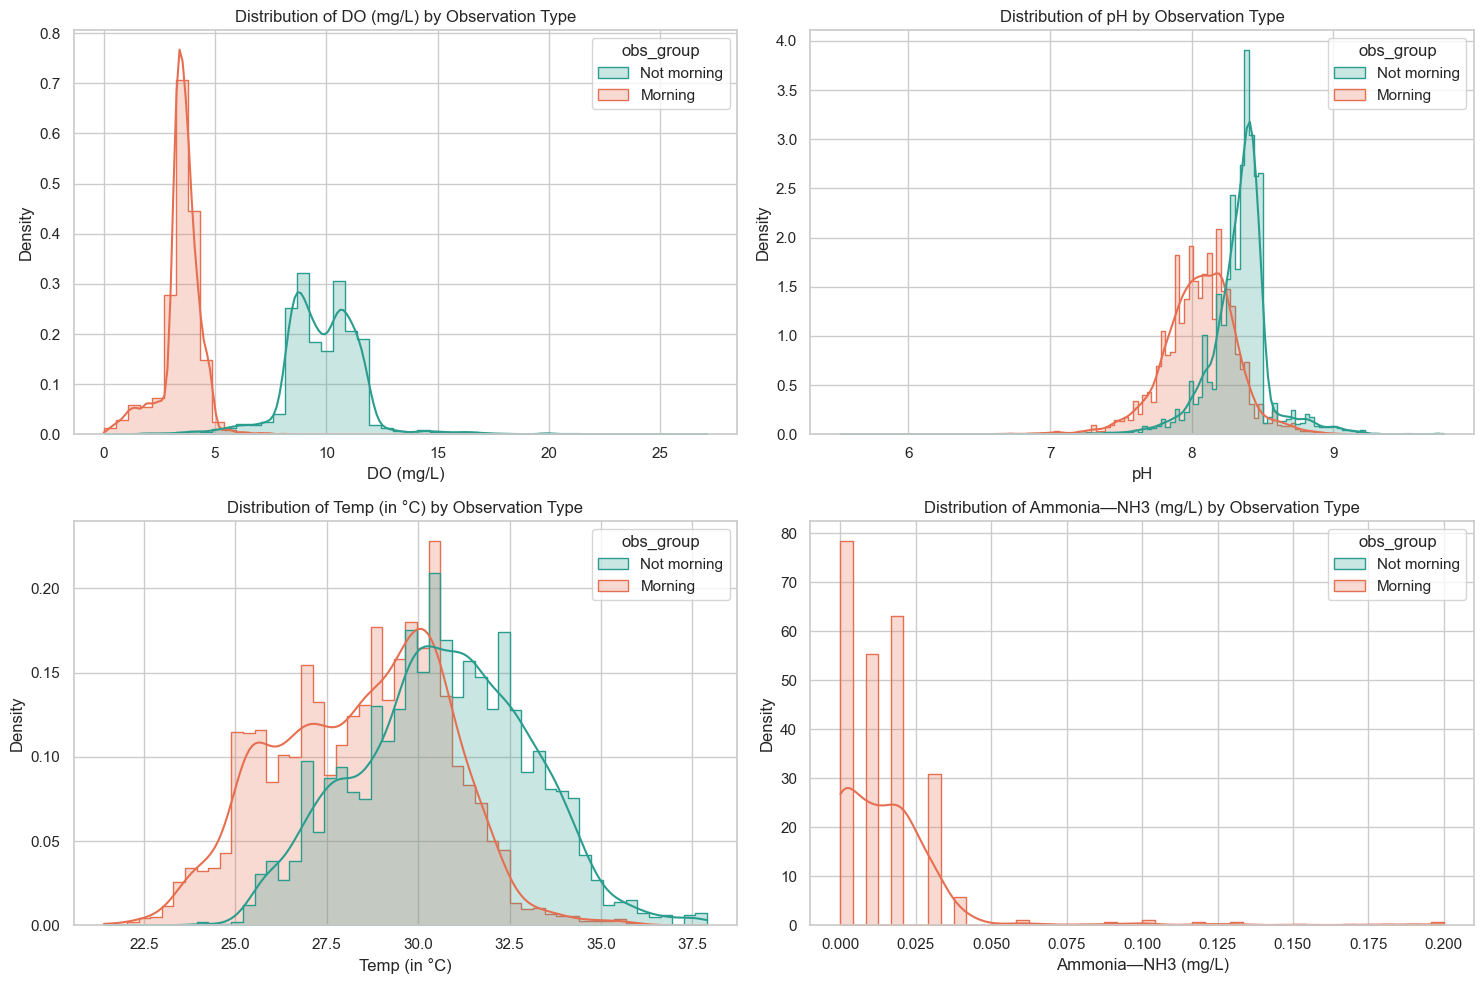

In [11]:
# Same histplot, split by Morning vs Not morning

plt.figure(figsize=(15, 10))

df['obs_group'] = df['Type'].astype(str).str.lower().eq('morning').map({True: 'Morning', False: 'Not morning'})
cols_to_plot = ['DO (mg/L)', 'pH', 'Temp (in °C)', 'Ammonia—NH3 (mg/L)']
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=df, x=col, hue='obs_group', kde=True, element='step', stat='density', common_norm=False, palette=['#2a9d8f', '#e76f51'])
    plt.title(f'Distribution of {col} by Observation Type')

plt.tight_layout()
plt.show()

## Correlation Analysis
Checking relationships between different water quality metrics.

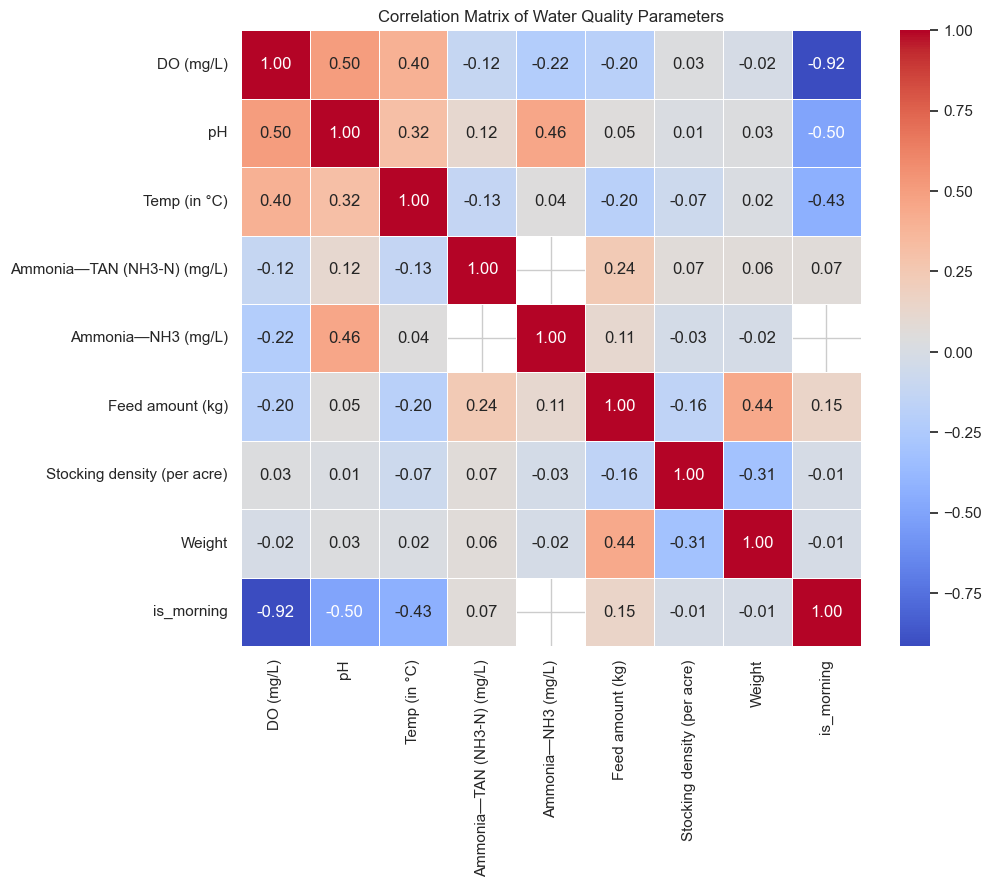

In [9]:
plt.figure(figsize=(10, 8))
corr_cols = numeric_cols + ['is_morning']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Water Quality Parameters')
plt.show()

## Comparing Regions
How does water quality vary by region?

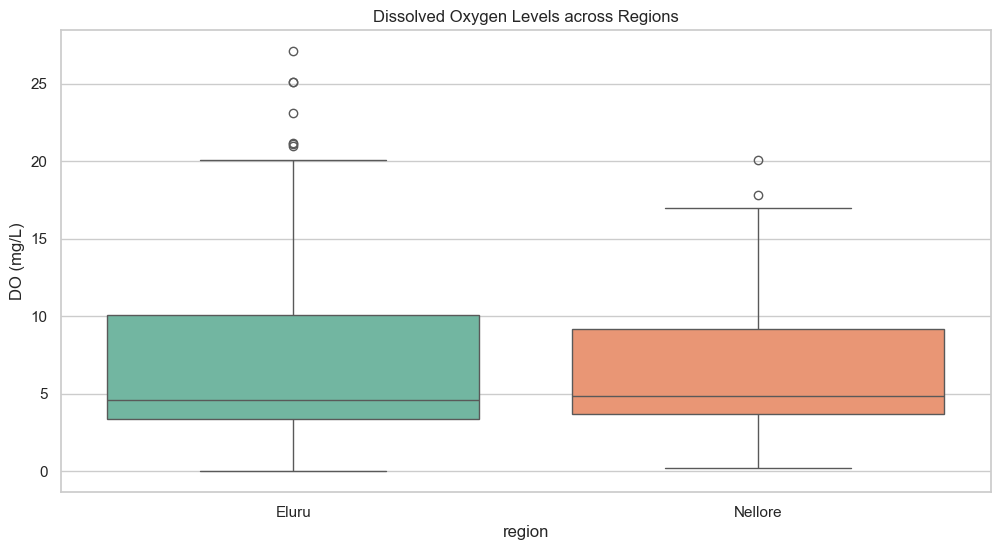

In [5]:
if 'region' in df.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='region', y='DO (mg/L)', data=df, hue='region', palette='Set2', legend=False)
    plt.title('Dissolved Oxygen Levels across Regions')
    plt.show()

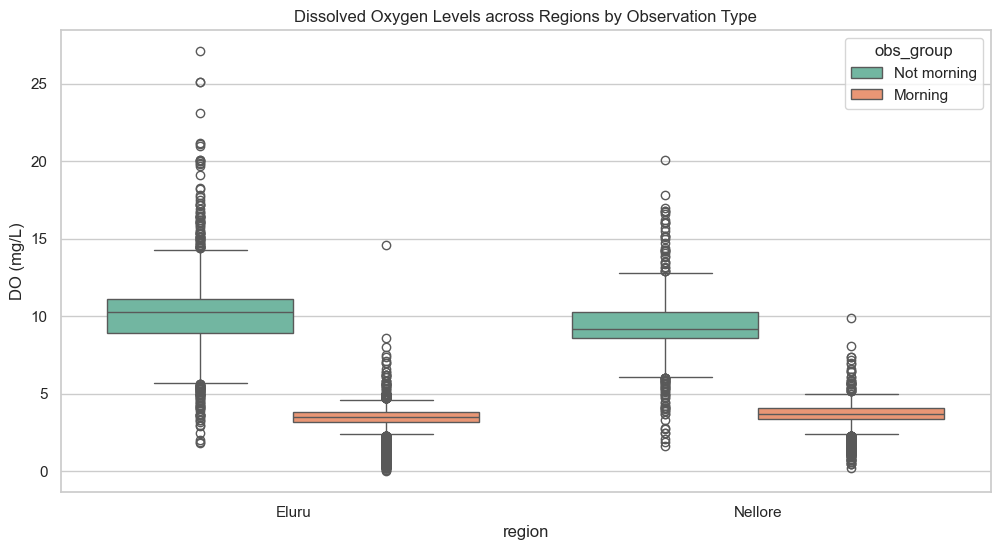

In [14]:
# Region comparison split by Morning vs Not morning

plot_df = df.copy()
plot_df['obs_group'] = plot_df['Type'].astype(str).str.lower().eq('morning').map({True: 'Morning', False: 'Not morning'})

if 'region' in plot_df.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='region', y='DO (mg/L)', data=plot_df, hue='obs_group', palette='Set2')
    plt.title('Dissolved Oxygen Levels across Regions by Observation Type')
    plt.show()

# Pond Measurement Frequency Analysis (Morning Only)

This section analyses **how often ponds are measured** using only `Type == "Morning"` observations.  
We examine:
- The distribution of gaps between successive measurements of the same pond  
- Which ponds are measured more / less often, and which have more regular schedules  
- How measurement frequency and regularity shift over time (by month and by quarter)

> **Regularity definition:** a pond's regularity is measured by the **coefficient of variation (CV = σ / μ)** of its inter-measurement gaps. A lower CV means more evenly-spaced measurements (higher regularity). A CV near 0 would mean perfectly uniform spacing; CV > 1 indicates very erratic visit schedules.

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")

# ── Load and filter ─────────────────────────────────────────────────────────
raw = pd.read_csv('data/water_quality.csv')
morning = raw[raw['Type'].str.lower() == 'morning'].copy()
morning['date'] = pd.to_datetime(morning['Date of data collection'], format='%m/%d/%Y')
morning = morning.drop_duplicates(subset=['date', 'pond_id'])   # remove the 1 duplicate date/pond pair

# Derived time fields
morning['year']    = morning['date'].dt.year
morning['month']   = morning['date'].dt.to_period('M')
morning['quarter'] = morning['date'].dt.to_period('Q')

# ── Inter-measurement gap table ──────────────────────────────────────────────
morning_s = morning.sort_values(['pond_id', 'date'])
morning_s['gap_days'] = morning_s.groupby('pond_id')['date'].diff().dt.days

gaps = morning_s.dropna(subset=['gap_days']).copy()

# ── Per-pond summary table (used across analyses) ────────────────────────────
def pond_stats(g):
    g_gaps = g['gap_days'].dropna()
    return pd.Series({
        'n_obs':        len(g),
        'first_date':   g['date'].min(),
        'last_date':    g['date'].max(),
        'span_days':    (g['date'].max() - g['date'].min()).days,
        'mean_gap':     g_gaps.mean() if len(g_gaps) else np.nan,
        'median_gap':   g_gaps.median() if len(g_gaps) else np.nan,
        'std_gap':      g_gaps.std()  if len(g_gaps) else np.nan,
        'max_gap':      g_gaps.max()  if len(g_gaps) else np.nan,
        'min_gap':      g_gaps.min()  if len(g_gaps) else np.nan,
        'cv_gap':       (g_gaps.std() / g_gaps.mean()) if (len(g_gaps) >= 2 and g_gaps.mean() > 0) else np.nan,
    })

pond_summary = morning_s.groupby('pond_id').apply(pond_stats, include_groups=False).reset_index()

print(f"Morning observations : {len(morning):,}")
print(f"Unique ponds         : {morning['pond_id'].nunique():,}")
print(f"Date range           : {morning['date'].min().date()} → {morning['date'].max().date()}")
print(f"Months covered       : {morning['month'].nunique()}")
print(f"Quarters covered     : {morning['quarter'].nunique()}")
print(f"\nInter-measurement gap summary (days):")
print(gaps['gap_days'].describe().round(1))

Morning observations : 5,904
Unique ponds         : 298
Date range           : 2021-06-19 → 2026-01-27
Months covered       : 56
Quarters covered     : 20

Inter-measurement gap summary (days):
count    5606.0
mean       28.6
std        41.5
min         1.0
25%        14.0
50%        23.0
75%        32.0
max      1158.0
Name: gap_days, dtype: float64


## Analysis 1 — Distribution of Inter-Measurement Gaps

For every pond we compute the number of days between consecutive morning visits. This shows the "typical" measurement cadence across the programme.

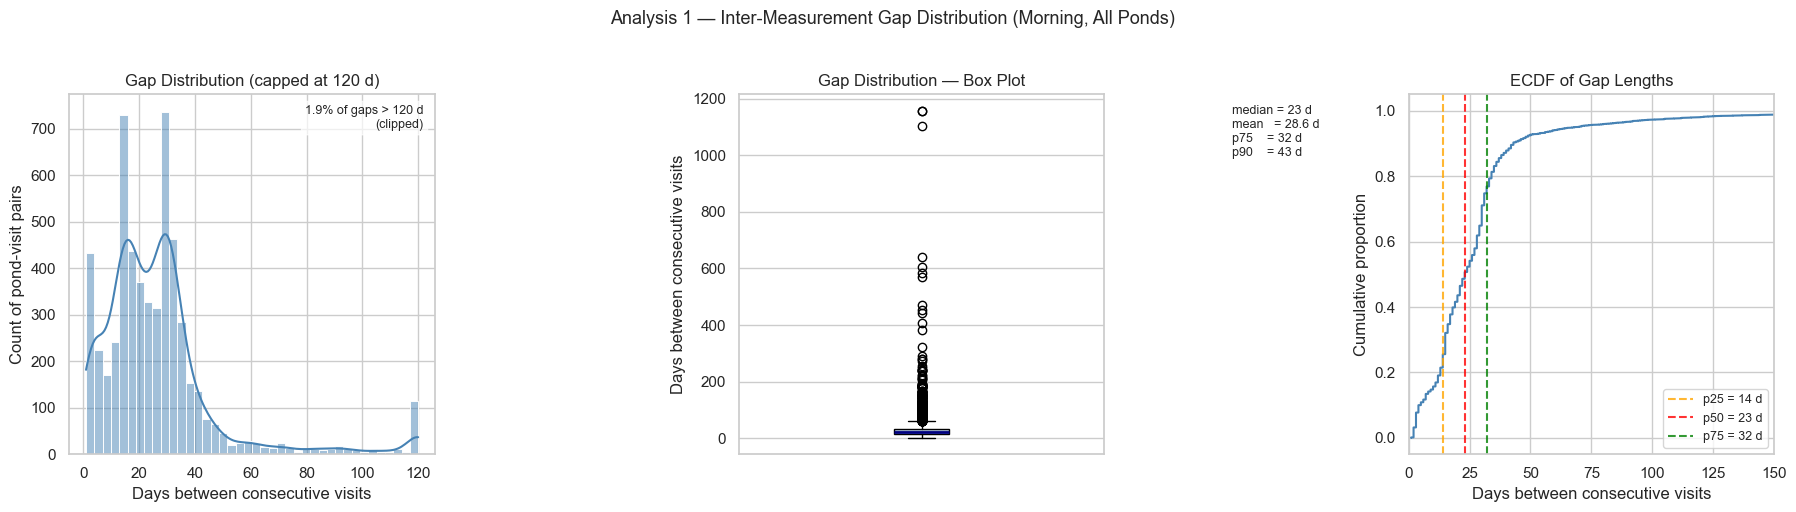

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Histogram with KDE (capped at 120 days to focus on the bulk) ─────────────
cap = 120
data_plot = gaps['gap_days'].clip(upper=cap)
ax = axes[0]
sns.histplot(data_plot, bins=40, kde=True, color='steelblue', ax=ax)
ax.set_title('Gap Distribution (capped at 120 d)')
ax.set_xlabel('Days between consecutive visits')
ax.set_ylabel('Count of pond-visit pairs')
pct_over_cap = (gaps['gap_days'] > cap).mean() * 100
ax.text(0.97, 0.97, f'{pct_over_cap:.1f}% of gaps > {cap} d\n(clipped)',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# ── Box-plot showing spread and outliers ─────────────────────────────────────
ax = axes[1]
ax.boxplot(gaps['gap_days'], vert=True, patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'),
           medianprops=dict(color='navy', linewidth=2))
ax.set_title('Gap Distribution — Box Plot')
ax.set_ylabel('Days between consecutive visits')
ax.set_xticks([])
stats_txt = (f"median = {gaps['gap_days'].median():.0f} d\n"
             f"mean   = {gaps['gap_days'].mean():.1f} d\n"
             f"p75    = {gaps['gap_days'].quantile(0.75):.0f} d\n"
             f"p90    = {gaps['gap_days'].quantile(0.90):.0f} d")
ax.text(1.35, 0.97, stats_txt, transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', alpha=0.8))

# ── ECDF ──────────────────────────────────────────────────────────────────────
ax = axes[2]
sorted_gaps = np.sort(gaps['gap_days'])
ecdf_y = np.arange(1, len(sorted_gaps) + 1) / len(sorted_gaps)
ax.plot(sorted_gaps, ecdf_y, color='steelblue')
ax.set_xlim(0, 150)
for p, c in [(0.25, 'orange'), (0.50, 'red'), (0.75, 'green')]:
    v = np.percentile(sorted_gaps, p * 100)
    ax.axvline(v, color=c, linestyle='--', alpha=0.8, label=f'p{int(p*100)} = {v:.0f} d')
ax.legend(fontsize=9)
ax.set_title('ECDF of Gap Lengths')
ax.set_xlabel('Days between consecutive visits')
ax.set_ylabel('Cumulative proportion')

plt.suptitle('Analysis 1 — Inter-Measurement Gap Distribution (Morning, All Ponds)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Analysis 2 — Gap Interval Categories

We bucket every inter-measurement gap into human-readable cadence bands (same-day, weekly, bi-weekly, monthly, etc.) to see which cadences are most common.

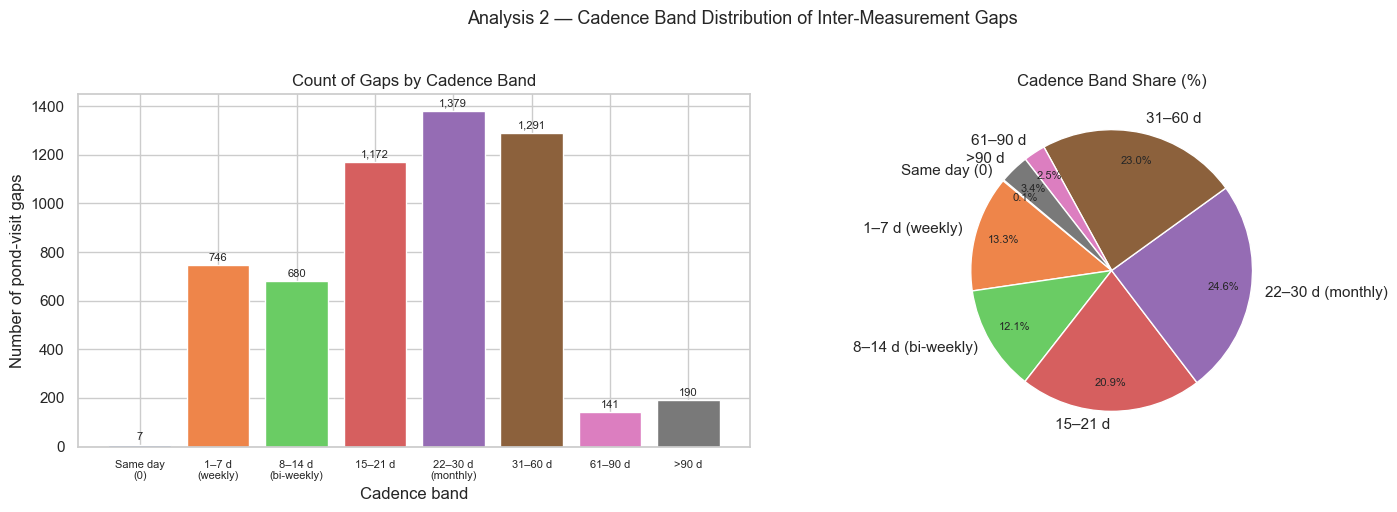

Cadence breakdown:
  Same day (0)             :    7  (0.1%)
  1–7 d (weekly)           :  746  (13.3%)
  8–14 d (bi-weekly)       :  680  (12.1%)
  15–21 d                  : 1172  (20.9%)
  22–30 d (monthly)        : 1379  (24.6%)
  31–60 d                  : 1291  (23.0%)
  61–90 d                  :  141  (2.5%)
  >90 d                    :  190  (3.4%)


In [8]:
bins   = [0, 1, 7, 14, 21, 30, 60, 90, float('inf')]
labels = ['Same day\n(0)', '1–7 d\n(weekly)', '8–14 d\n(bi-weekly)',
          '15–21 d', '22–30 d\n(monthly)', '31–60 d', '61–90 d', '>90 d']

gaps['gap_cat'] = pd.cut(gaps['gap_days'], bins=bins, labels=labels, right=True)
cat_counts = gaps['gap_cat'].value_counts().reindex(labels)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Bar chart ─────────────────────────────────────────────────────────────────
ax = axes[0]
colors = sns.color_palette('muted', n_colors=len(labels))
bars = ax.bar(labels, cat_counts.values, color=colors, edgecolor='white')
ax.set_title('Count of Gaps by Cadence Band')
ax.set_xlabel('Cadence band')
ax.set_ylabel('Number of pond-visit gaps')
for bar, v in zip(bars, cat_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            f'{v:,}', ha='center', va='bottom', fontsize=8)
ax.tick_params(axis='x', labelsize=8)

# ── Pie chart ─────────────────────────────────────────────────────────────────
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    cat_counts.dropna(),
    labels=[l.replace('\n', ' ') for l in cat_counts.dropna().index],
    autopct='%1.1f%%',
    colors=colors[:len(cat_counts.dropna())],
    startangle=140,
    pctdistance=0.8,
)
for t in autotexts:
    t.set_fontsize(8)
ax.set_title('Cadence Band Share (%)')

plt.suptitle('Analysis 2 — Cadence Band Distribution of Inter-Measurement Gaps', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Cadence breakdown:")
pct = (cat_counts / cat_counts.sum() * 100).round(1)
for band, n, p in zip(labels, cat_counts.values, pct.values):
    print(f"  {band.replace(chr(10),' '):25s}: {n:4d}  ({p:.1f}%)")

## Analysis 3 — Total Observations per Pond

How many morning measurements did each pond accumulate?  
We look at the distribution across all ponds, then rank the top and bottom ponds.

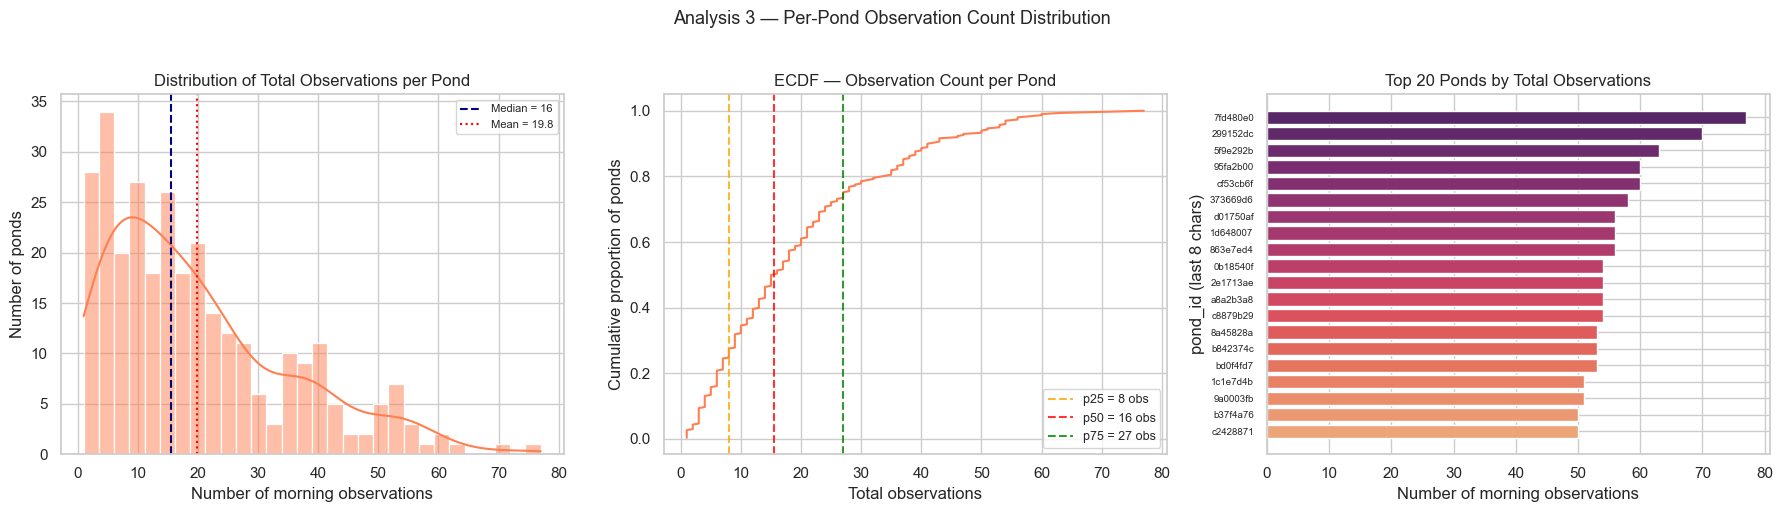

Ponds with ≥ 30 obs: 67 (22.5% of ponds)
Ponds with ≤ 5 obs : 47 (15.8% of ponds)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Histogram of per-pond total counts ───────────────────────────────────────
ax = axes[0]
sns.histplot(pond_summary['n_obs'], bins=30, kde=True, color='coral', ax=ax)
ax.axvline(pond_summary['n_obs'].median(), color='navy', linestyle='--',
           label=f"Median = {pond_summary['n_obs'].median():.0f}")
ax.axvline(pond_summary['n_obs'].mean(), color='red', linestyle=':',
           label=f"Mean = {pond_summary['n_obs'].mean():.1f}")
ax.legend(fontsize=8)
ax.set_title('Distribution of Total Observations per Pond')
ax.set_xlabel('Number of morning observations')
ax.set_ylabel('Number of ponds')

# ── ECDF of observation counts ────────────────────────────────────────────────
ax = axes[1]
sorted_n = np.sort(pond_summary['n_obs'])
ecdf_y   = np.arange(1, len(sorted_n) + 1) / len(sorted_n)
ax.plot(sorted_n, ecdf_y, color='coral')
for p, c in [(0.25, 'orange'), (0.50, 'red'), (0.75, 'green')]:
    v = np.percentile(sorted_n, p * 100)
    ax.axvline(v, color=c, linestyle='--', alpha=0.8, label=f'p{int(p*100)} = {v:.0f} obs')
ax.legend(fontsize=9)
ax.set_title('ECDF — Observation Count per Pond')
ax.set_xlabel('Total observations')
ax.set_ylabel('Cumulative proportion of ponds')

# ── Top 20 ponds by observation count ─────────────────────────────────────────
ax = axes[2]
top20 = pond_summary.nlargest(20, 'n_obs').sort_values('n_obs')
short_id = top20['pond_id'].str[-8:]
colors_bar = sns.color_palette('flare', n_colors=len(top20))
ax.barh(short_id, top20['n_obs'], color=colors_bar)
ax.set_title('Top 20 Ponds by Total Observations')
ax.set_xlabel('Number of morning observations')
ax.set_ylabel('pond_id (last 8 chars)')
ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Analysis 3 — Per-Pond Observation Count Distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Ponds with ≥ 30 obs: {(pond_summary['n_obs'] >= 30).sum()} "
      f"({(pond_summary['n_obs'] >= 30).mean()*100:.1f}% of ponds)")
print(f"Ponds with ≤ 5 obs : {(pond_summary['n_obs'] <= 5).sum()} "
      f"({(pond_summary['n_obs'] <= 5).mean()*100:.1f}% of ponds)")

## Analysis 4 — Ponds Measured per Day (Time Series)

How many distinct ponds receive a morning measurement on each calendar day?  
This reveals the programme's operational intensity over time.

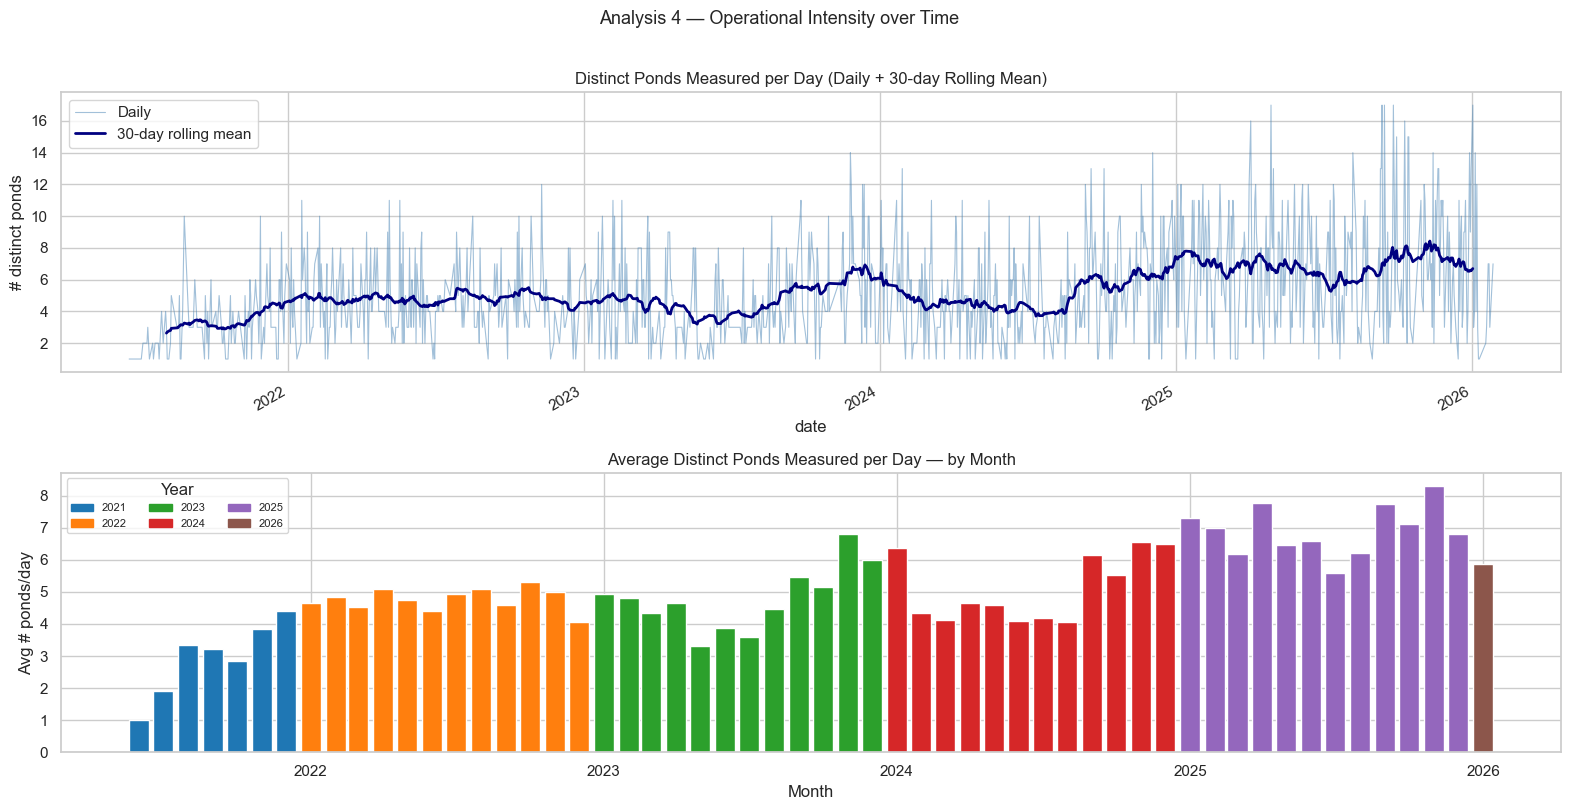

In [10]:
daily_ponds = morning.groupby('date')['pond_id'].nunique().rename('n_ponds')
daily_ponds = daily_ponds.sort_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

# ── Daily count raw + 30-day rolling mean ─────────────────────────────────────
ax = axes[0]
daily_ponds.plot(ax=ax, color='steelblue', alpha=0.5, linewidth=0.8, label='Daily')
daily_ponds.rolling(30, center=True).mean().plot(ax=ax, color='navy', linewidth=2,
                                                  label='30-day rolling mean')
ax.set_title('Distinct Ponds Measured per Day (Daily + 30-day Rolling Mean)')
ax.set_ylabel('# distinct ponds')
ax.legend()

# ── Monthly average ponds per day ────────────────────────────────────────────
ax = axes[1]
monthly_avg = morning.groupby('month')['date'].apply(
    lambda d: morning.loc[d.index].groupby('date')['pond_id'].nunique().mean()
).reset_index()
monthly_avg.columns = ['month', 'avg_ponds_per_day']
monthly_avg['month_dt'] = monthly_avg['month'].dt.to_timestamp()

# Color bars by year
years = monthly_avg['month_dt'].dt.year
palette = {y: c for y, c in zip(sorted(years.unique()), sns.color_palette('tab10', n_colors=years.nunique()))}
bar_colors = [palette[y] for y in years]
ax.bar(monthly_avg['month_dt'], monthly_avg['avg_ponds_per_day'],
       width=25, color=bar_colors, align='center')
ax.set_title('Average Distinct Ponds Measured per Day — by Month')
ax.set_ylabel('Avg # ponds/day')
ax.set_xlabel('Month')
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=str(y)) for y, c in palette.items()]
ax.legend(handles=legend_handles, title='Year', fontsize=8, ncol=3)

plt.suptitle('Analysis 4 — Operational Intensity over Time', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [3]:
# Deciles of daily unique pond counts by region (Nellore vs Eluru)

import pandas as pd

raw = pd.read_csv('data/water_quality.csv')
morning = raw[raw['Type'].str.lower() == 'morning'].copy()
morning['date'] = pd.to_datetime(morning['Date of data collection'], format='%m/%d/%Y')

region_col = 'region' if 'region' in morning.columns else None
if region_col is None:
    raise KeyError("Expected a 'region' column in data/water_quality.csv")

regions = ['nellore', 'eluru']
daily_region_counts = (
    morning[morning[region_col].str.lower().isin(regions)]
    .groupby([morning['date'].dt.normalize(), morning[region_col].str.lower()])['pond_id']
    .nunique()
    .rename('unique_ponds')
    .reset_index()
)
daily_region_counts.columns = ['date', 'region', 'unique_ponds']

period_rows = []
for region in regions:
    region_daily = daily_region_counts[daily_region_counts['region'] == region]['unique_ponds']
    if region_daily.empty:
        continue
    deciles = region_daily.quantile([i / 10 for i in range(1, 10)]).round(1)
    period_rows.extend([
        {
            'region': region.title(),
            'decile': f'P{int(q * 100)}',
            'unique_ponds_per_day': value,
        }
        for q, value in deciles.items()
    ])

decile_df = pd.DataFrame(period_rows)
decile_df

,region,decile,unique_ponds_per_day
0,Nellore,P10,1.0
1,Nellore,P20,2.0
2,Nellore,P30,2.0
3,Nellore,P40,3.0
4,Nellore,P50,3.0
5,Nellore,P60,3.0
6,Nellore,P70,4.0
7,Nellore,P80,4.0
8,Nellore,P90,5.0
9,Eluru,P10,2.0


In [13]:
# Verify that the Morning filter is meaningful

morning_check = df[df['Type'].astype(str).str.lower().eq('morning')].copy()

summary = pd.DataFrame([
    {'metric': 'total rows in df', 'value': len(df)},
    {'metric': 'rows in morning', 'value': len(morning_check)},
    {'metric': 'rows not morning', 'value': len(df) - len(morning_check)},
    {'metric': 'morning share (%)', 'value': round(len(morning_check) / len(df) * 100, 1)},
    {'metric': 'unique Type values in morning', 'value': morning_check['Type'].nunique(dropna=True)},
    {'metric': 'all rows in morning are Type == Morning', 'value': morning_check['Type'].astype(str).str.lower().eq('morning').all()},
])

type_counts = df['Type'].value_counts(dropna=False).rename_axis('Type').reset_index(name='rows')
type_counts
summary

,metric,value
0,total rows in df,11433
1,rows in morning,5905
2,rows not morning,5528
3,morning share (%),51.6
4,unique Type values in morning,1
5,all rows in morning are Type == Morning,True


## Analysis 5 — Monthly Observation Counts and Unique Ponds

How do total morning measurements and the number of distinct ponds measured change across calendar months?

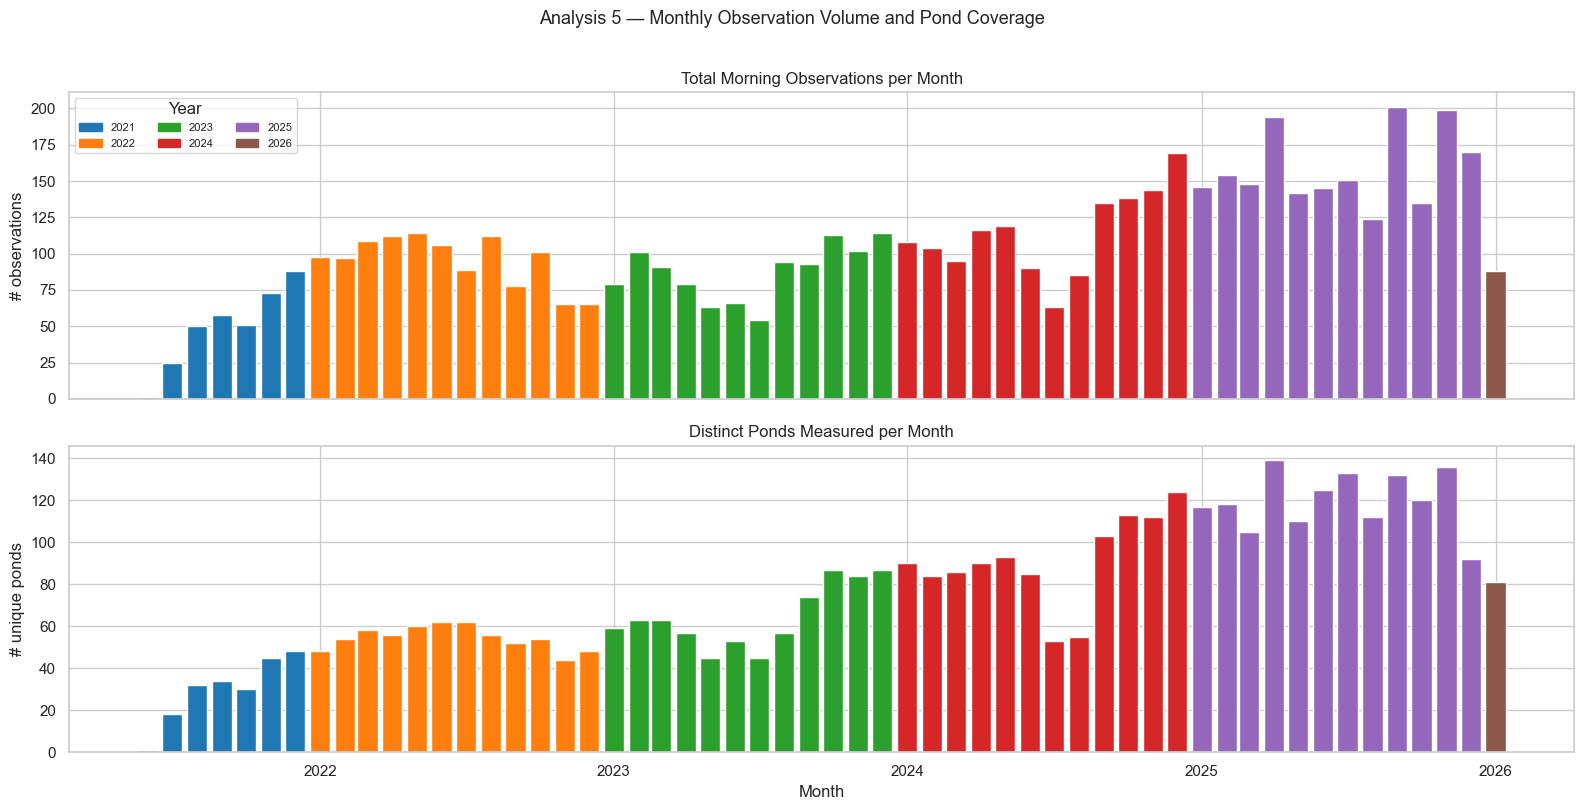

Peak month (obs)  : 2025-09 — 201 observations
Peak month (ponds): 2025-04 — 139 unique ponds


In [11]:
monthly = morning.groupby('month').agg(
    total_obs=('pond_id', 'count'),
    unique_ponds=('pond_id', 'nunique'),
).reset_index()
monthly['month_dt'] = monthly['month'].dt.to_timestamp()
monthly['year'] = monthly['month_dt'].dt.year

palette = {y: c for y, c in zip(sorted(monthly['year'].unique()),
           sns.color_palette('tab10', n_colors=monthly['year'].nunique()))}
bar_colors = [palette[y] for y in monthly['year']]

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

ax = axes[0]
ax.bar(monthly['month_dt'], monthly['total_obs'], width=25, color=bar_colors)
ax.set_title('Total Morning Observations per Month')
ax.set_ylabel('# observations')
legend_handles = [Patch(color=c, label=str(y)) for y, c in palette.items()]
ax.legend(handles=legend_handles, title='Year', fontsize=8, ncol=3)

ax = axes[1]
ax.bar(monthly['month_dt'], monthly['unique_ponds'], width=25, color=bar_colors)
ax.set_title('Distinct Ponds Measured per Month')
ax.set_ylabel('# unique ponds')
ax.set_xlabel('Month')

plt.suptitle('Analysis 5 — Monthly Observation Volume and Pond Coverage', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"Peak month (obs)  : {monthly.loc[monthly.total_obs.idxmax(), 'month']} — "
      f"{monthly['total_obs'].max():,} observations")
print(f"Peak month (ponds): {monthly.loc[monthly.unique_ponds.idxmax(), 'month']} — "
      f"{monthly['unique_ponds'].max()} unique ponds")

## Analysis 6 — Quarterly Trends

Aggregating to quarters smooths out month-to-month noise. We compare total observations and unique ponds by quarter, and look at the average gap between measurements within each quarter.

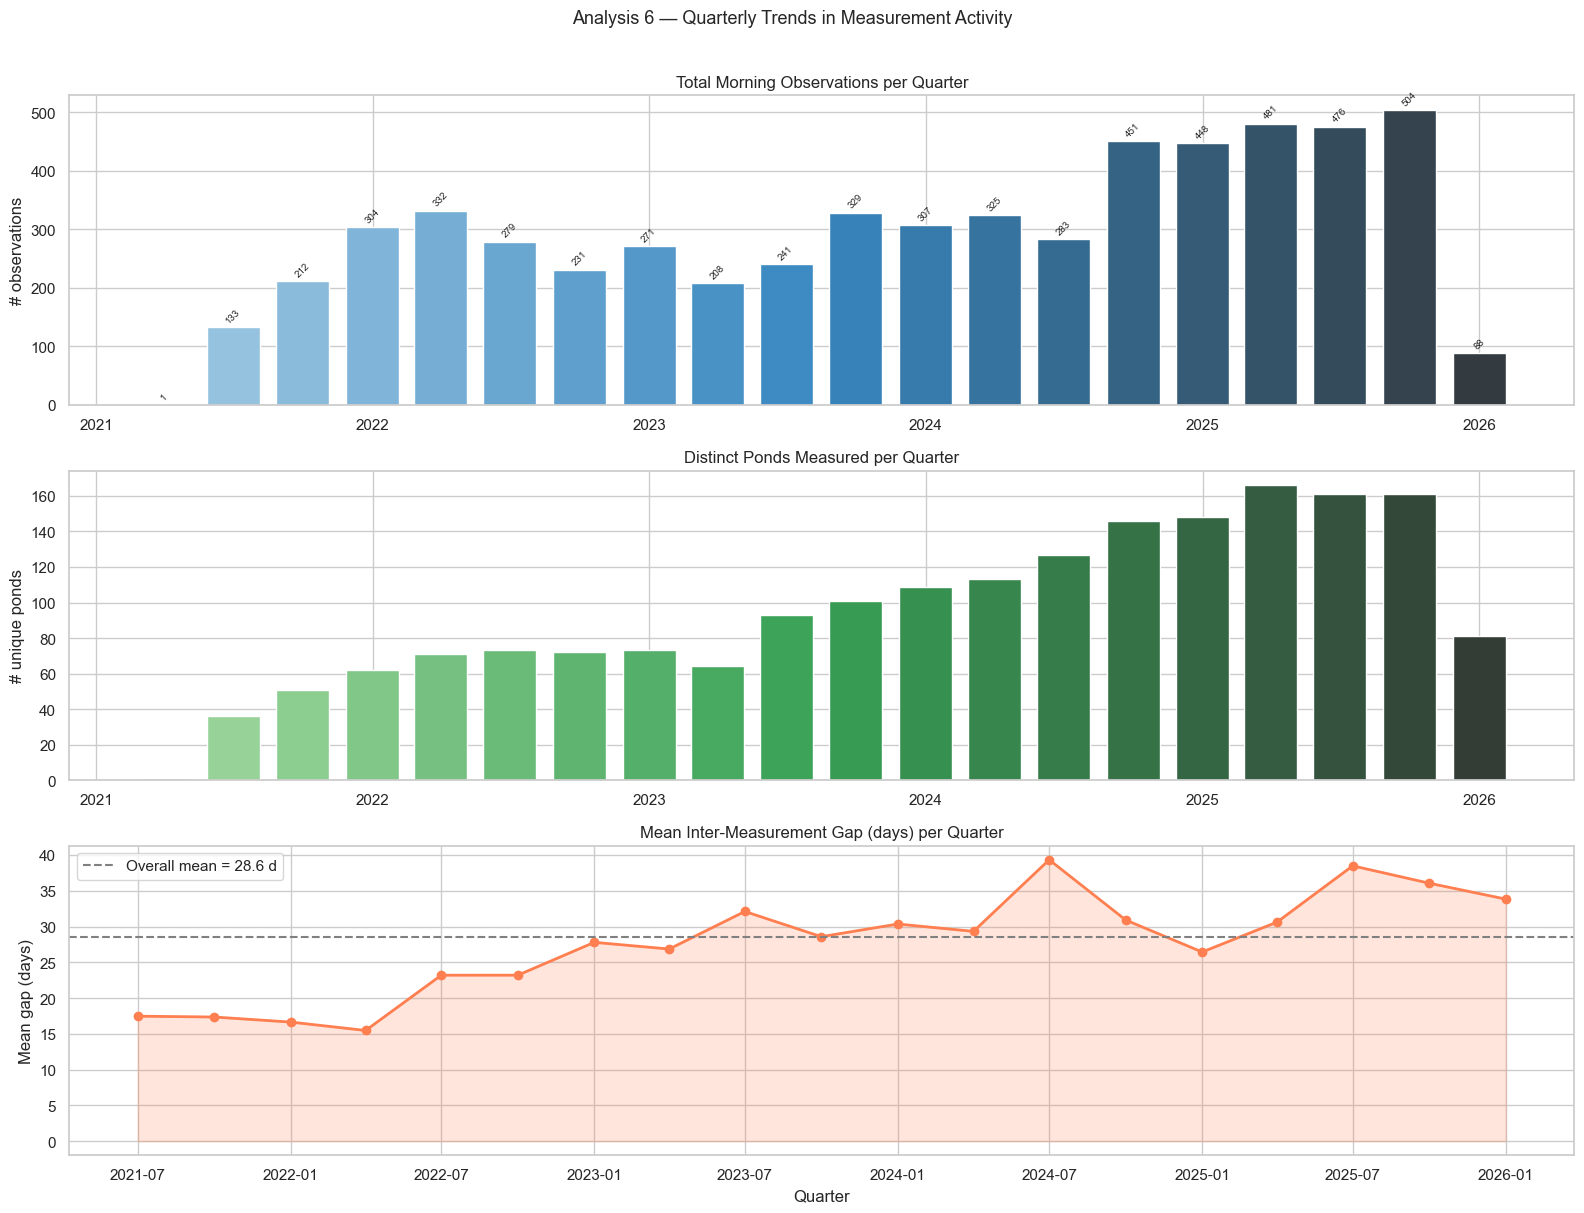

In [12]:
quarterly = morning.groupby('quarter').agg(
    total_obs=('pond_id', 'count'),
    unique_ponds=('pond_id', 'nunique'),
).reset_index()
quarterly['q_dt'] = quarterly['quarter'].dt.to_timestamp()
quarterly['q_label'] = quarterly['quarter'].astype(str)

q_gaps = gaps.copy()
q_gaps['quarter'] = q_gaps['date'].dt.to_period('Q')
quarterly_gap = q_gaps.groupby('quarter')['gap_days'].mean().reset_index()
quarterly_gap['q_dt'] = quarterly_gap['quarter'].dt.to_timestamp()

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=False)

# ── Total obs per quarter ─────────────────────────────────────────────────────
ax = axes[0]
ax.bar(quarterly['q_dt'], quarterly['total_obs'], width=70,
       color=sns.color_palette('Blues_d', n_colors=len(quarterly)))
ax.set_title('Total Morning Observations per Quarter')
ax.set_ylabel('# observations')
for _, row in quarterly.iterrows():
    ax.text(row['q_dt'], row['total_obs'] + 5, str(int(row['total_obs'])),
            ha='center', va='bottom', fontsize=7, rotation=45)

# ── Unique ponds per quarter ──────────────────────────────────────────────────
ax = axes[1]
ax.bar(quarterly['q_dt'], quarterly['unique_ponds'], width=70,
       color=sns.color_palette('Greens_d', n_colors=len(quarterly)))
ax.set_title('Distinct Ponds Measured per Quarter')
ax.set_ylabel('# unique ponds')

# ── Mean gap per quarter ──────────────────────────────────────────────────────
ax = axes[2]
ax.plot(quarterly_gap['q_dt'], quarterly_gap['gap_days'],
        marker='o', color='coral', linewidth=2)
ax.fill_between(quarterly_gap['q_dt'], quarterly_gap['gap_days'],
                alpha=0.2, color='coral')
ax.set_title('Mean Inter-Measurement Gap (days) per Quarter')
ax.set_ylabel('Mean gap (days)')
ax.set_xlabel('Quarter')
ax.axhline(gaps['gap_days'].mean(), color='grey', linestyle='--',
           label=f"Overall mean = {gaps['gap_days'].mean():.1f} d")
ax.legend()

plt.suptitle('Analysis 6 — Quarterly Trends in Measurement Activity', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Analysis 7 — Measurement Presence Heatmap (Ponds × Months)

For the 50 most-observed ponds, this heatmap shows how many morning visits occurred in each calendar month — revealing which ponds are observed consistently across the timeline vs. those that appear only in certain periods.

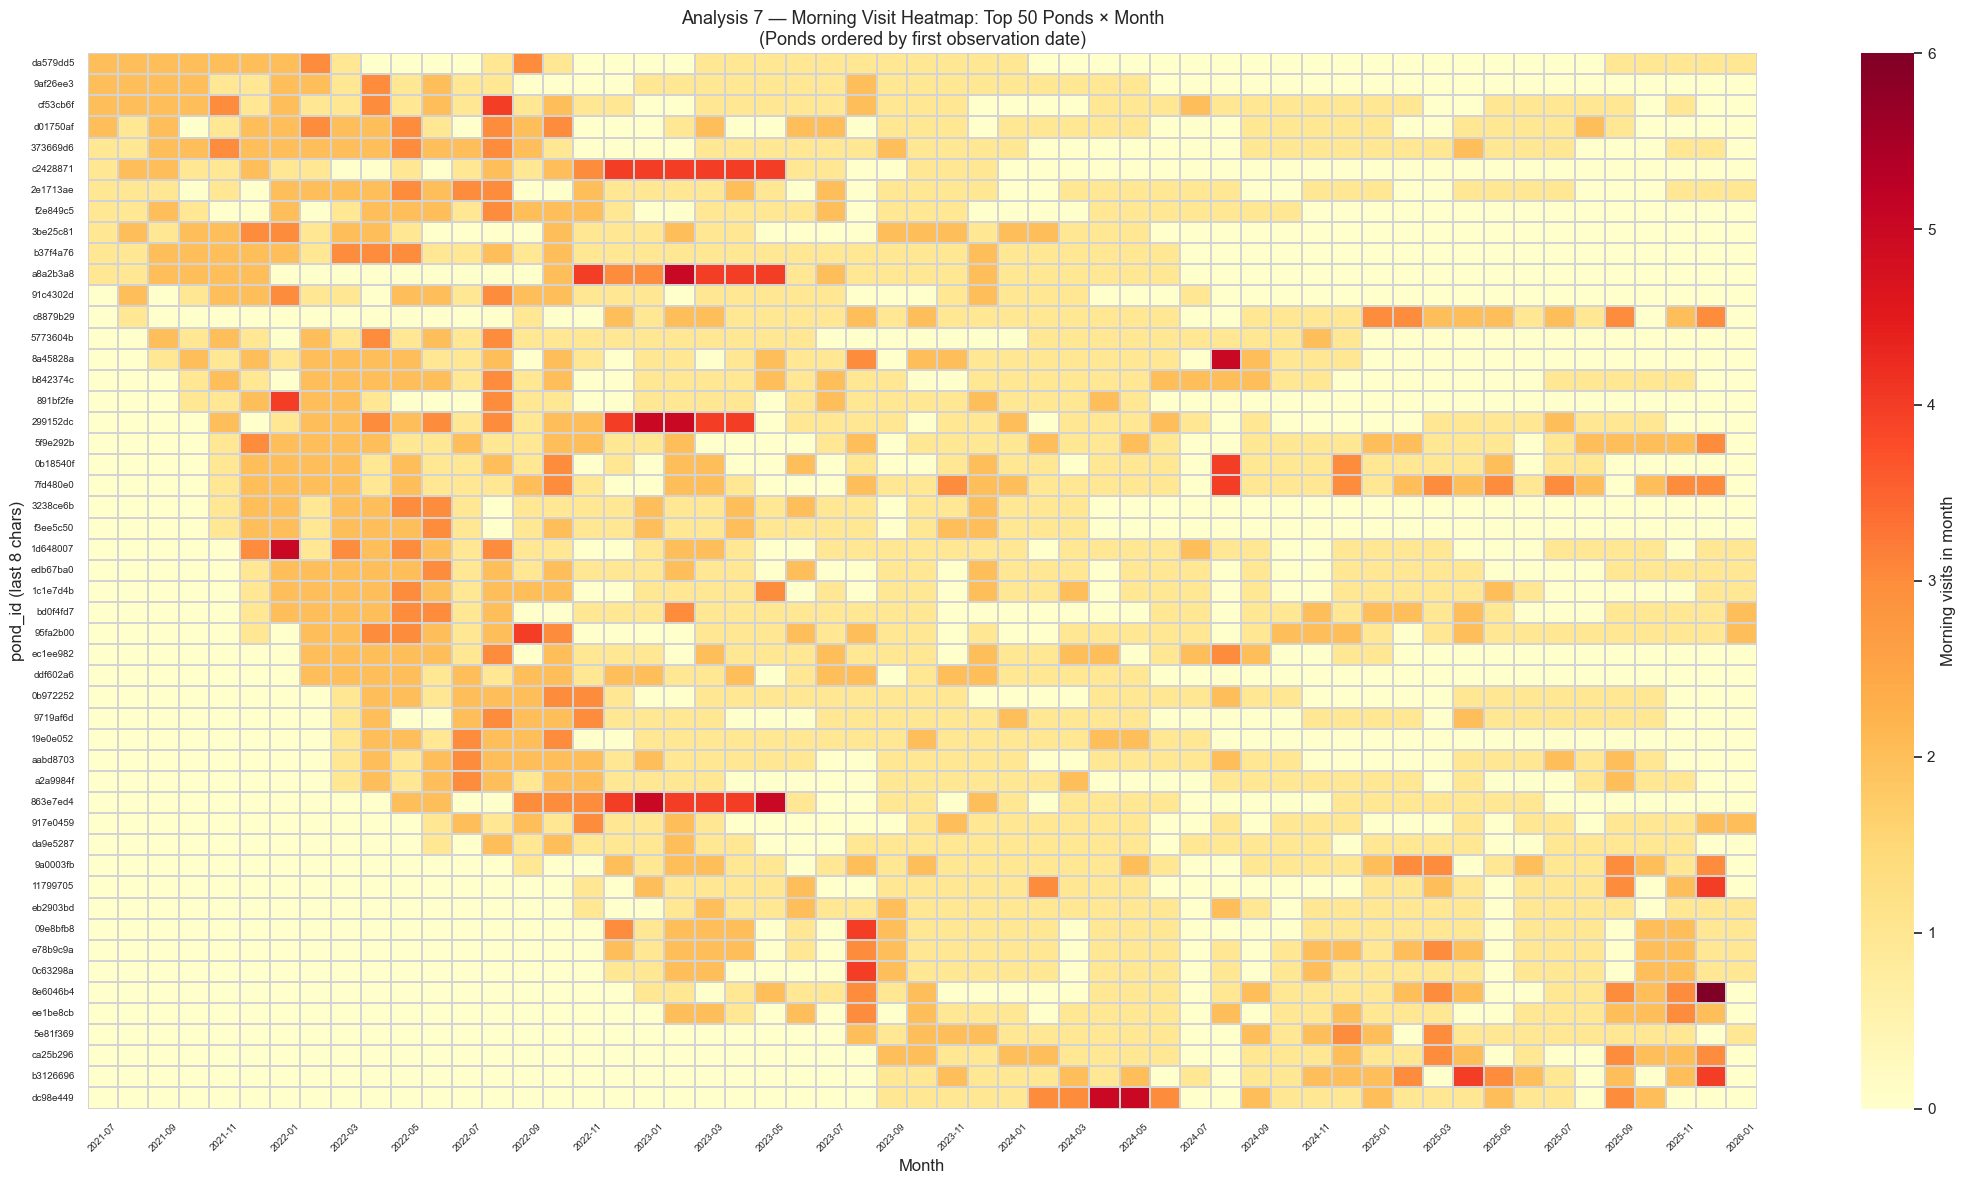

In [13]:
TOP_N = 50
top_ponds = pond_summary.nlargest(TOP_N, 'n_obs')['pond_id'].tolist()

heat_df = (morning[morning['pond_id'].isin(top_ponds)]
           .groupby(['pond_id', 'month'])
           .size()
           .unstack(fill_value=0))

# Sort ponds by first observation date
first_obs_order = pond_summary.set_index('pond_id').loc[top_ponds, 'first_date'].sort_values().index
heat_df = heat_df.reindex(first_obs_order)
heat_df.index = [idx[-8:] for idx in heat_df.index]   # shorten IDs for readability
heat_df.columns = heat_df.columns.astype(str)

# Keep only months with ≥1 observation for any of these ponds (avoids huge empty columns)
heat_df = heat_df.loc[:, (heat_df > 0).any()]

fig, ax = plt.subplots(figsize=(22, 12))
sns.heatmap(heat_df, cmap='YlOrRd', linewidths=0.3, linecolor='lightgrey',
            cbar_kws={'label': 'Morning visits in month'},
            xticklabels=2, ax=ax)
ax.set_title(f'Analysis 7 — Morning Visit Heatmap: Top {TOP_N} Ponds × Month\n'
             '(Ponds ordered by first observation date)', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('pond_id (last 8 chars)')
ax.tick_params(axis='x', labelsize=7, rotation=45)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

## Analysis 8 — Regularity: Distribution of CV Across Ponds

**Regularity** is defined as the **coefficient of variation (CV = σ/μ)** of the inter-measurement gaps for each pond.

- **CV → 0** : perfectly regular (every N days like clockwork)  
- **CV > 1** : highly erratic (very variable spacing between visits)

We restrict to ponds with **≥ 5 gaps** so the CV estimate is meaningful.

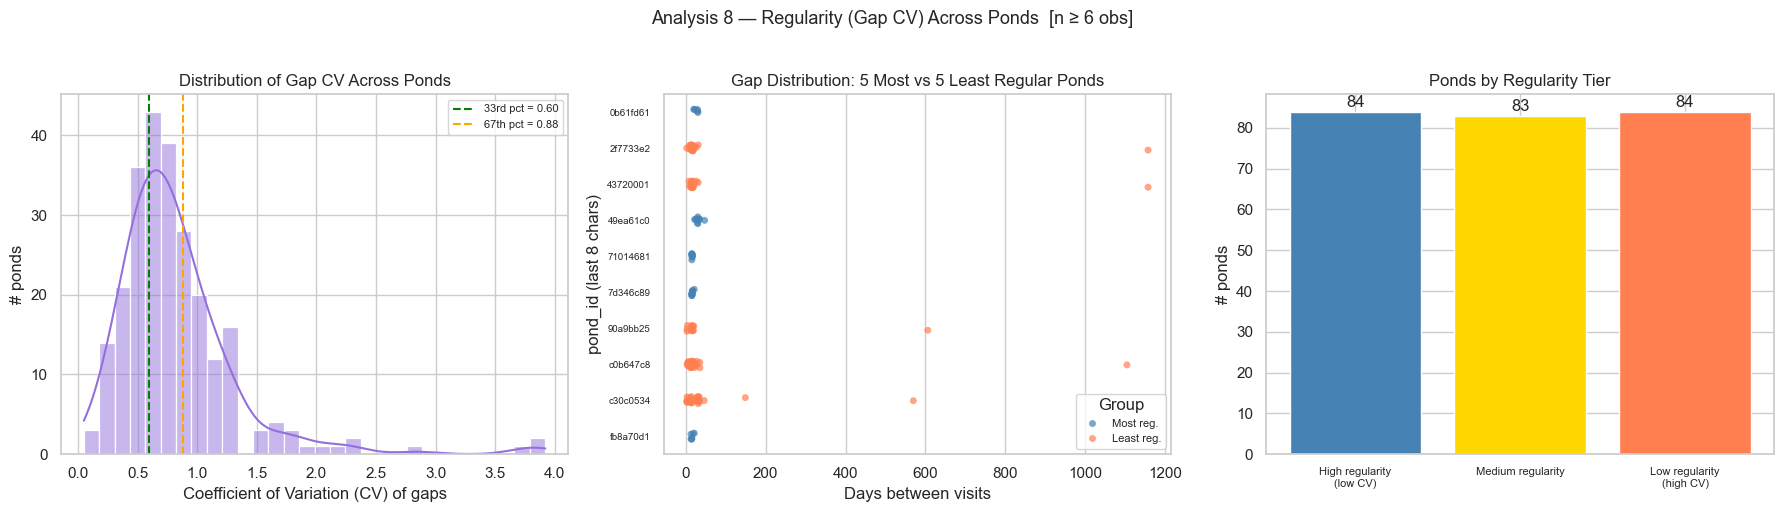

Ponds with ≥ 6 obs (enough for CV): 251
CV: median=0.72, mean=0.83, range=[0.05, 3.92]


In [14]:
MIN_GAPS = 5
reg_df = pond_summary.dropna(subset=['cv_gap'])
reg_df = reg_df[reg_df['n_obs'] > MIN_GAPS].copy()   # need n_obs-1 >= 5 gaps

# Regularity tiers based on CV percentiles
q33, q67 = reg_df['cv_gap'].quantile([1/3, 2/3]).values
reg_df['regularity_tier'] = pd.cut(
    reg_df['cv_gap'],
    bins=[-np.inf, q33, q67, np.inf],
    labels=['High regularity\n(low CV)', 'Medium regularity', 'Low regularity\n(high CV)']
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Histogram of CVs ──────────────────────────────────────────────────────────
ax = axes[0]
sns.histplot(reg_df['cv_gap'], bins=30, kde=True, color='mediumpurple', ax=ax)
ax.axvline(q33, color='green',  linestyle='--', label=f'33rd pct = {q33:.2f}')
ax.axvline(q67, color='orange', linestyle='--', label=f'67th pct = {q67:.2f}')
ax.legend(fontsize=8)
ax.set_title('Distribution of Gap CV Across Ponds')
ax.set_xlabel('Coefficient of Variation (CV) of gaps')
ax.set_ylabel('# ponds')

# ── Most and least regular ponds — gap strip plots ────────────────────────────
ax = axes[1]
most_reg   = reg_df.nsmallest(5, 'cv_gap')['pond_id'].tolist()
least_reg  = reg_df.nlargest(5,  'cv_gap')['pond_id'].tolist()
focus_ids  = most_reg + least_reg
focus_tags = ['Most reg.' if p in most_reg else 'Least reg.' for p in focus_ids]

focus_gaps = gaps[gaps['pond_id'].isin(focus_ids)].copy()
focus_gaps['tag'] = focus_gaps['pond_id'].map(
    {p: t for p, t in zip(focus_ids, focus_tags)})
focus_gaps['short_id'] = focus_gaps['pond_id'].str[-8:]

palette_strip = {'Most reg.': 'steelblue', 'Least reg.': 'coral'}
sns.stripplot(data=focus_gaps, y='short_id', x='gap_days', hue='tag',
              palette=palette_strip, jitter=True, alpha=0.7, ax=ax)
ax.set_title('Gap Distribution: 5 Most vs 5 Least Regular Ponds')
ax.set_xlabel('Days between visits')
ax.set_ylabel('pond_id (last 8 chars)')
ax.tick_params(axis='y', labelsize=7)
ax.legend(title='Group', fontsize=8)

# ── Regularity-tier bar counts ────────────────────────────────────────────────
ax = axes[2]
tier_counts = reg_df['regularity_tier'].value_counts().reindex(
    ['High regularity\n(low CV)', 'Medium regularity', 'Low regularity\n(high CV)'])
colors_t = ['steelblue', 'gold', 'coral']
ax.bar(tier_counts.index, tier_counts.values, color=colors_t)
ax.set_title('Ponds by Regularity Tier')
ax.set_ylabel('# ponds')
ax.tick_params(axis='x', labelsize=8)
for i, (v) in enumerate(tier_counts.values):
    ax.text(i, v + 0.5, str(v), ha='center', va='bottom')

plt.suptitle(f'Analysis 8 — Regularity (Gap CV) Across Ponds  [n ≥ {MIN_GAPS+1} obs]',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Ponds with ≥ {MIN_GAPS+1} obs (enough for CV): {len(reg_df)}")
print(f"CV: median={reg_df['cv_gap'].median():.2f}, "
      f"mean={reg_df['cv_gap'].mean():.2f}, "
      f"range=[{reg_df['cv_gap'].min():.2f}, {reg_df['cv_gap'].max():.2f}]")

## Analysis 9 — Regularity vs Measurement Frequency

Do more-frequently-measured ponds also tend to be more regular, or are the two dimensions independent?  
Each point is a pond; colour encodes total observation count.

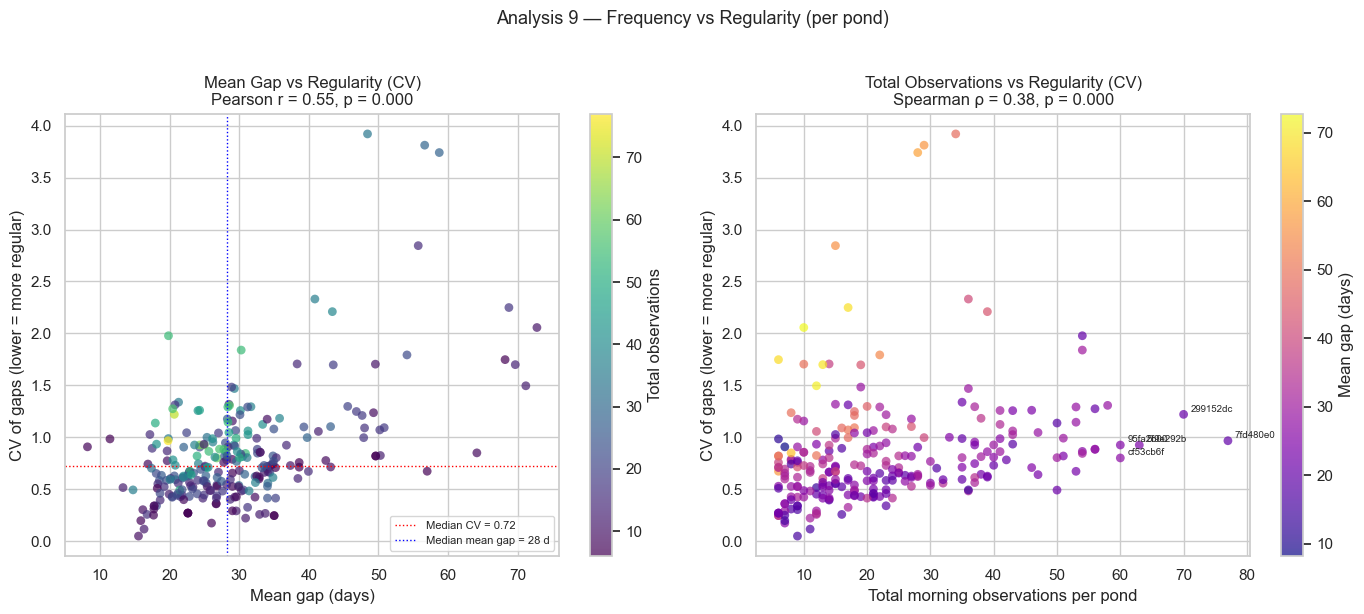

In [15]:
from scipy.stats import pearsonr, spearmanr

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Scatter: mean gap vs CV, coloured by total obs ────────────────────────────
ax = axes[0]
sc = ax.scatter(reg_df['mean_gap'], reg_df['cv_gap'],
                c=reg_df['n_obs'], cmap='viridis', alpha=0.7, edgecolors='none', s=40)
plt.colorbar(sc, ax=ax, label='Total observations')
r, p = pearsonr(reg_df['mean_gap'], reg_df['cv_gap'])
ax.set_title(f'Mean Gap vs Regularity (CV)\nPearson r = {r:.2f}, p = {p:.3f}')
ax.set_xlabel('Mean gap (days)')
ax.set_ylabel('CV of gaps (lower = more regular)')
ax.axhline(reg_df['cv_gap'].median(), color='red', linestyle=':', linewidth=1,
           label=f'Median CV = {reg_df["cv_gap"].median():.2f}')
ax.axvline(reg_df['mean_gap'].median(), color='blue', linestyle=':', linewidth=1,
           label=f'Median mean gap = {reg_df["mean_gap"].median():.0f} d')
ax.legend(fontsize=8)

# ── Scatter: n_obs vs CV ──────────────────────────────────────────────────────
ax = axes[1]
sc2 = ax.scatter(reg_df['n_obs'], reg_df['cv_gap'],
                 c=reg_df['mean_gap'], cmap='plasma', alpha=0.7, edgecolors='none', s=40)
plt.colorbar(sc2, ax=ax, label='Mean gap (days)')
rho, p2 = spearmanr(reg_df['n_obs'], reg_df['cv_gap'])
ax.set_title(f'Total Observations vs Regularity (CV)\nSpearman ρ = {rho:.2f}, p = {p2:.3f}')
ax.set_xlabel('Total morning observations per pond')
ax.set_ylabel('CV of gaps (lower = more regular)')

# Annotate top-5 most-observed
for _, row in reg_df.nlargest(5, 'n_obs').iterrows():
    ax.annotate(row['pond_id'][-8:], (row['n_obs'], row['cv_gap']),
                fontsize=7, xytext=(5, 2), textcoords='offset points')

plt.suptitle('Analysis 9 — Frequency vs Regularity (per pond)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Analysis 10 — Pond Tenure (Active Span) and Observation Density

**Tenure** = days between the first and last morning observation of a pond.  
We compare tenure against total observations to distinguish:
- **Active ponds**: long tenure, many observations → measured throughout
- **Dense but short**: short tenure, many obs → intensive early/late monitoring
- **Sparse long**: long tenure, few obs → only occasionally checked

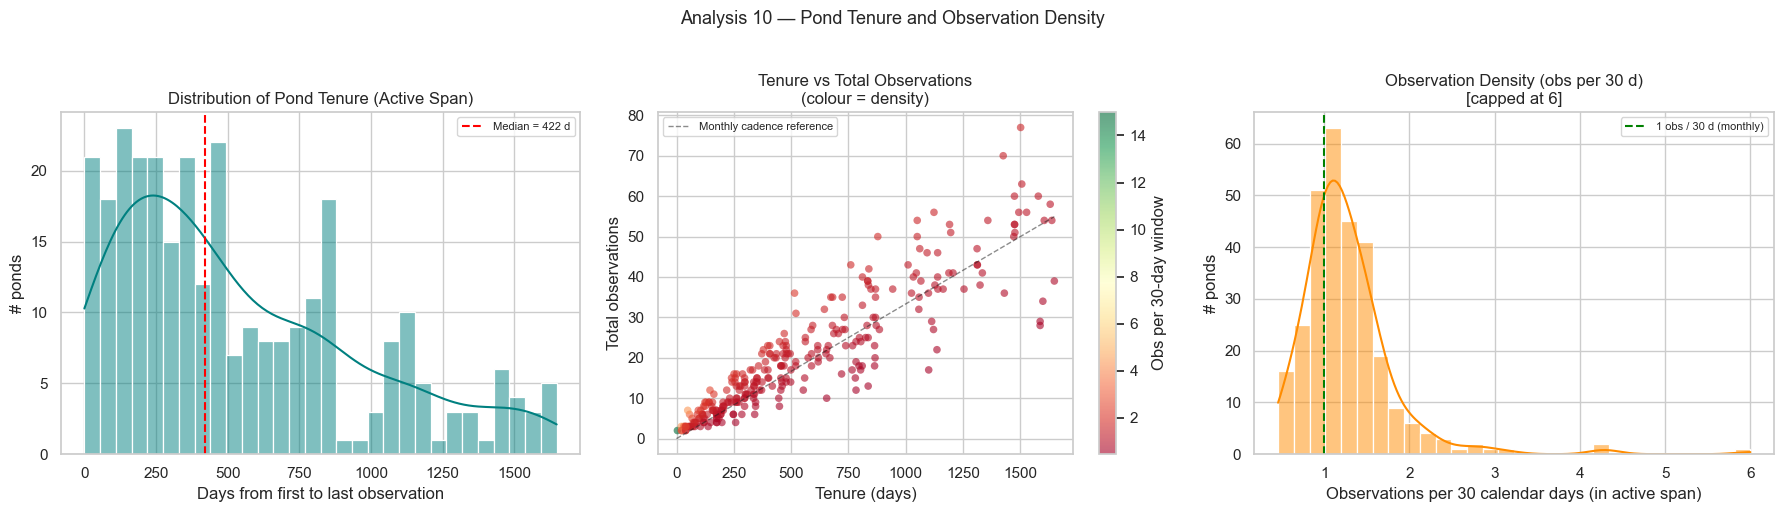

In [16]:
ps = pond_summary.copy()
# obs density: observations per 30 days of active span (avoid div-by-zero for 1-obs ponds)
ps['obs_per_30d'] = np.where(ps['span_days'] > 0,
                              ps['n_obs'] / ps['span_days'] * 30, np.nan)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Tenure distribution ───────────────────────────────────────────────────────
ax = axes[0]
sns.histplot(ps['span_days'].dropna(), bins=30, kde=True, color='teal', ax=ax)
ax.axvline(ps['span_days'].median(), color='red', linestyle='--',
           label=f'Median = {ps["span_days"].median():.0f} d')
ax.legend(fontsize=8)
ax.set_title('Distribution of Pond Tenure (Active Span)')
ax.set_xlabel('Days from first to last observation')
ax.set_ylabel('# ponds')

# ── Tenure vs total observations ──────────────────────────────────────────────
ax = axes[1]
sc = ax.scatter(ps['span_days'], ps['n_obs'],
                c=ps['obs_per_30d'], cmap='RdYlGn', alpha=0.6, edgecolors='none', s=30)
plt.colorbar(sc, ax=ax, label='Obs per 30-day window')
# Reference line: if measured every 30 d, n_obs = span / 30
span_ref = np.linspace(0, ps['span_days'].max(), 100)
ax.plot(span_ref, span_ref / 30, 'k--', linewidth=1, alpha=0.5,
        label='Monthly cadence reference')
ax.legend(fontsize=8)
ax.set_title('Tenure vs Total Observations\n(colour = density)')
ax.set_xlabel('Tenure (days)')
ax.set_ylabel('Total observations')

# ── Observation density distribution ─────────────────────────────────────────
ax = axes[2]
sns.histplot(ps['obs_per_30d'].dropna().clip(upper=6), bins=30, kde=True,
             color='darkorange', ax=ax)
ax.axvline(1.0, color='green', linestyle='--', label='1 obs / 30 d (monthly)')
ax.legend(fontsize=8)
ax.set_title('Observation Density (obs per 30 d)\n[capped at 6]')
ax.set_xlabel('Observations per 30 calendar days (in active span)')
ax.set_ylabel('# ponds')

plt.suptitle('Analysis 10 — Pond Tenure and Observation Density', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Analysis 11 — Longest Consecutive Gap per Pond

Even a regularly-measured pond may have had a long break at some point. We look at the **maximum gap** (the longest stretch without a visit) for each pond to identify monitoring blind-spots.

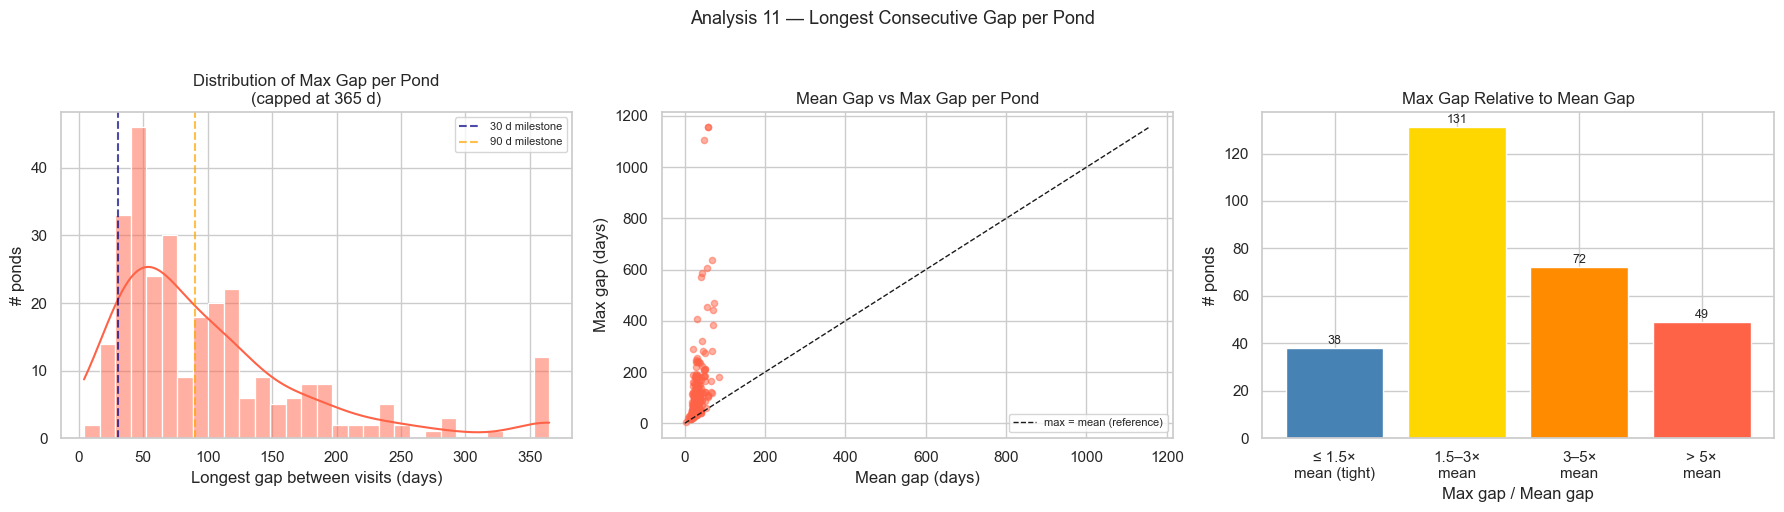

Ponds whose longest gap exceeded 90 days: 44.1%


In [17]:
multi_obs = pond_summary[pond_summary['n_obs'] >= 2].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Distribution of max gap ───────────────────────────────────────────────────
ax = axes[0]
sns.histplot(multi_obs['max_gap'].clip(upper=365), bins=30, kde=True,
             color='tomato', ax=ax)
ax.axvline(30, color='navy', linestyle='--', alpha=0.7, label='30 d milestone')
ax.axvline(90, color='orange', linestyle='--', alpha=0.7, label='90 d milestone')
ax.legend(fontsize=8)
ax.set_title('Distribution of Max Gap per Pond\n(capped at 365 d)')
ax.set_xlabel('Longest gap between visits (days)')
ax.set_ylabel('# ponds')

# ── Max gap vs mean gap ───────────────────────────────────────────────────────
ax = axes[1]
plot_df = multi_obs.dropna(subset=['mean_gap', 'max_gap'])
ax.scatter(plot_df['mean_gap'], plot_df['max_gap'],
           alpha=0.5, color='tomato', s=20)
lim = max(plot_df['mean_gap'].max(), plot_df['max_gap'].max())
ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='max = mean (reference)')
ax.set_title('Mean Gap vs Max Gap per Pond')
ax.set_xlabel('Mean gap (days)')
ax.set_ylabel('Max gap (days)')
ax.legend(fontsize=8)

# ── Category: ponds whose max gap ≤ 2× mean (tight) vs > 2× ─────────────────
ax = axes[2]
plot_df2 = multi_obs.dropna(subset=['mean_gap', 'max_gap']).copy()
plot_df2['max_vs_mean'] = plot_df2['max_gap'] / plot_df2['mean_gap']
cat_labels = ['≤ 1.5×\nmean (tight)', '1.5–3×\nmean', '3–5×\nmean', '> 5×\nmean']
cat_bins   = [0, 1.5, 3, 5, np.inf]
plot_df2['max_cat'] = pd.cut(plot_df2['max_vs_mean'], bins=cat_bins, labels=cat_labels)
cat_c = plot_df2['max_cat'].value_counts().reindex(cat_labels)
ax.bar(cat_labels, cat_c.values, color=['steelblue', 'gold', 'darkorange', 'tomato'])
ax.set_title('Max Gap Relative to Mean Gap')
ax.set_xlabel('Max gap / Mean gap')
ax.set_ylabel('# ponds')
for i, v in enumerate(cat_c.values):
    ax.text(i, v + 0.5, str(v), ha='center', va='bottom', fontsize=9)

plt.suptitle('Analysis 11 — Longest Consecutive Gap per Pond', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

over90 = (multi_obs['max_gap'] > 90).mean() * 100
print(f"Ponds whose longest gap exceeded 90 days: {over90:.1f}%")

## Analysis 12 — When Do Ponds Enter the Dataset? (Cohort Entry over Time)

When was each pond first observed? This shows whether the monitoring programme enrolled ponds continuously or in discrete waves.

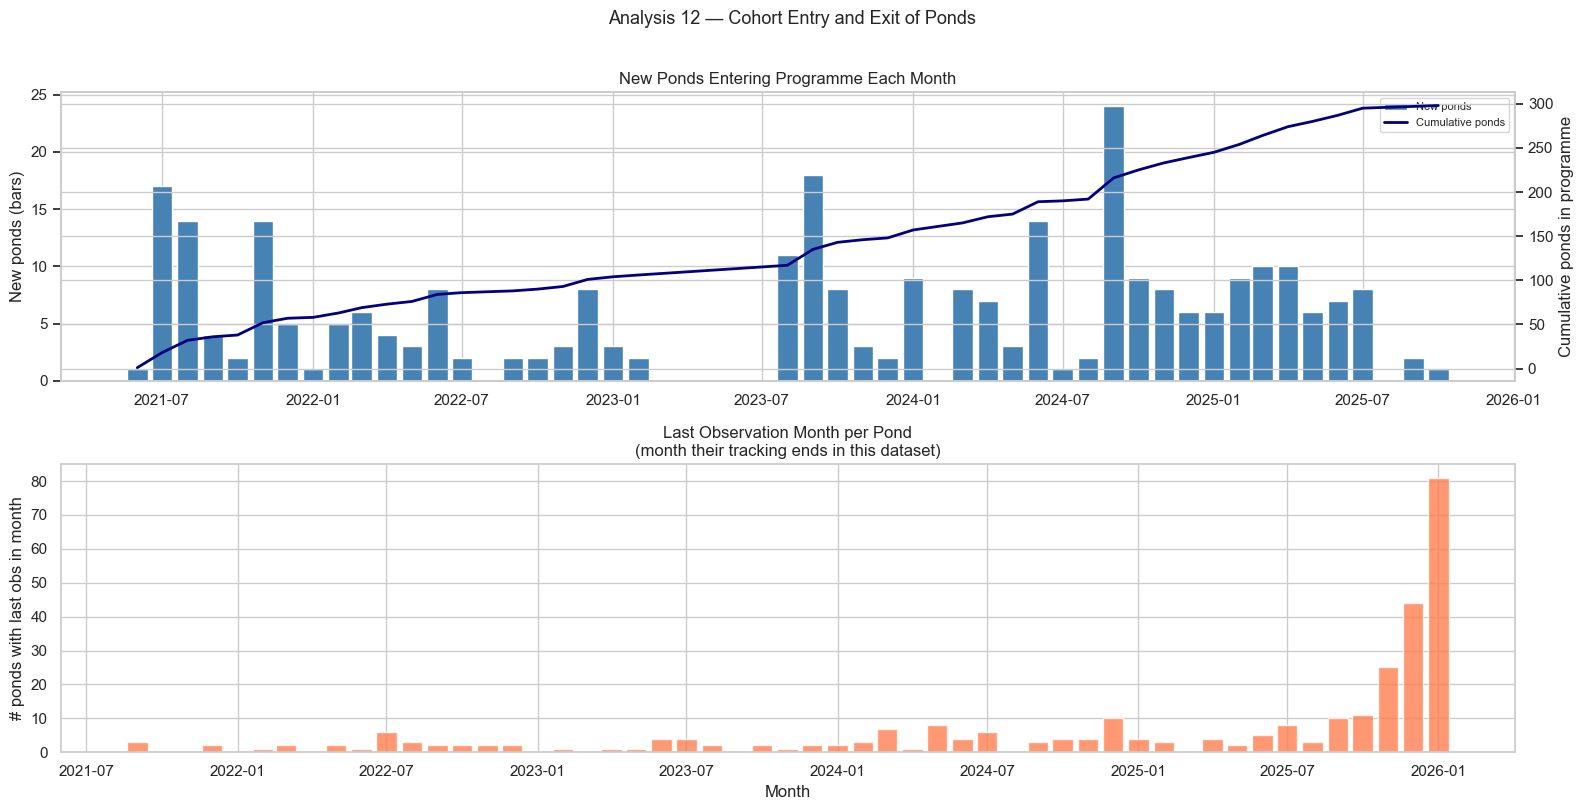

Total ponds first observed: 298
Month with most new ponds: 2024-09 (24 ponds)


In [18]:
pond_summary['first_month'] = pond_summary['first_date'].dt.to_period('M')
pond_summary['last_month']  = pond_summary['last_date'].dt.to_period('M')

entry_by_month = pond_summary.groupby('first_month').size().reset_index(name='new_ponds')
entry_by_month['month_dt'] = entry_by_month['first_month'].dt.to_timestamp()
entry_by_month['cum_ponds'] = entry_by_month['new_ponds'].cumsum()

exit_by_month = pond_summary.groupby('last_month').size().reset_index(name='last_obs_ponds')
exit_by_month['month_dt'] = exit_by_month['last_month'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

# ── New ponds entering each month ─────────────────────────────────────────────
ax = axes[0]
ax.bar(entry_by_month['month_dt'], entry_by_month['new_ponds'],
       width=25, color='steelblue', label='New ponds')
ax2 = ax.twinx()
ax2.plot(entry_by_month['month_dt'], entry_by_month['cum_ponds'],
         color='navy', linewidth=2, label='Cumulative ponds')
ax2.set_ylabel('Cumulative ponds in programme')
ax.set_title('New Ponds Entering Programme Each Month')
ax.set_ylabel('New ponds (bars)')
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8)

# ── Last obs month distribution ───────────────────────────────────────────────
ax = axes[1]
ax.bar(exit_by_month['month_dt'], exit_by_month['last_obs_ponds'],
       width=25, color='coral', alpha=0.8)
ax.set_title('Last Observation Month per Pond\n(month their tracking ends in this dataset)')
ax.set_ylabel('# ponds with last obs in month')
ax.set_xlabel('Month')

plt.suptitle('Analysis 12 — Cohort Entry and Exit of Ponds', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"Total ponds first observed: {len(pond_summary)}")
print(f"Month with most new ponds: {entry_by_month.loc[entry_by_month.new_ponds.idxmax(), 'first_month']} "
      f"({entry_by_month['new_ponds'].max()} ponds)")

## Analysis 13 — Regularity Variation by Quarter

Does the mix of measurement regularity (gap CV) within the active pond population change across quarters?  
A boxplot per quarter shows whether scheduling became more/less consistent over time.

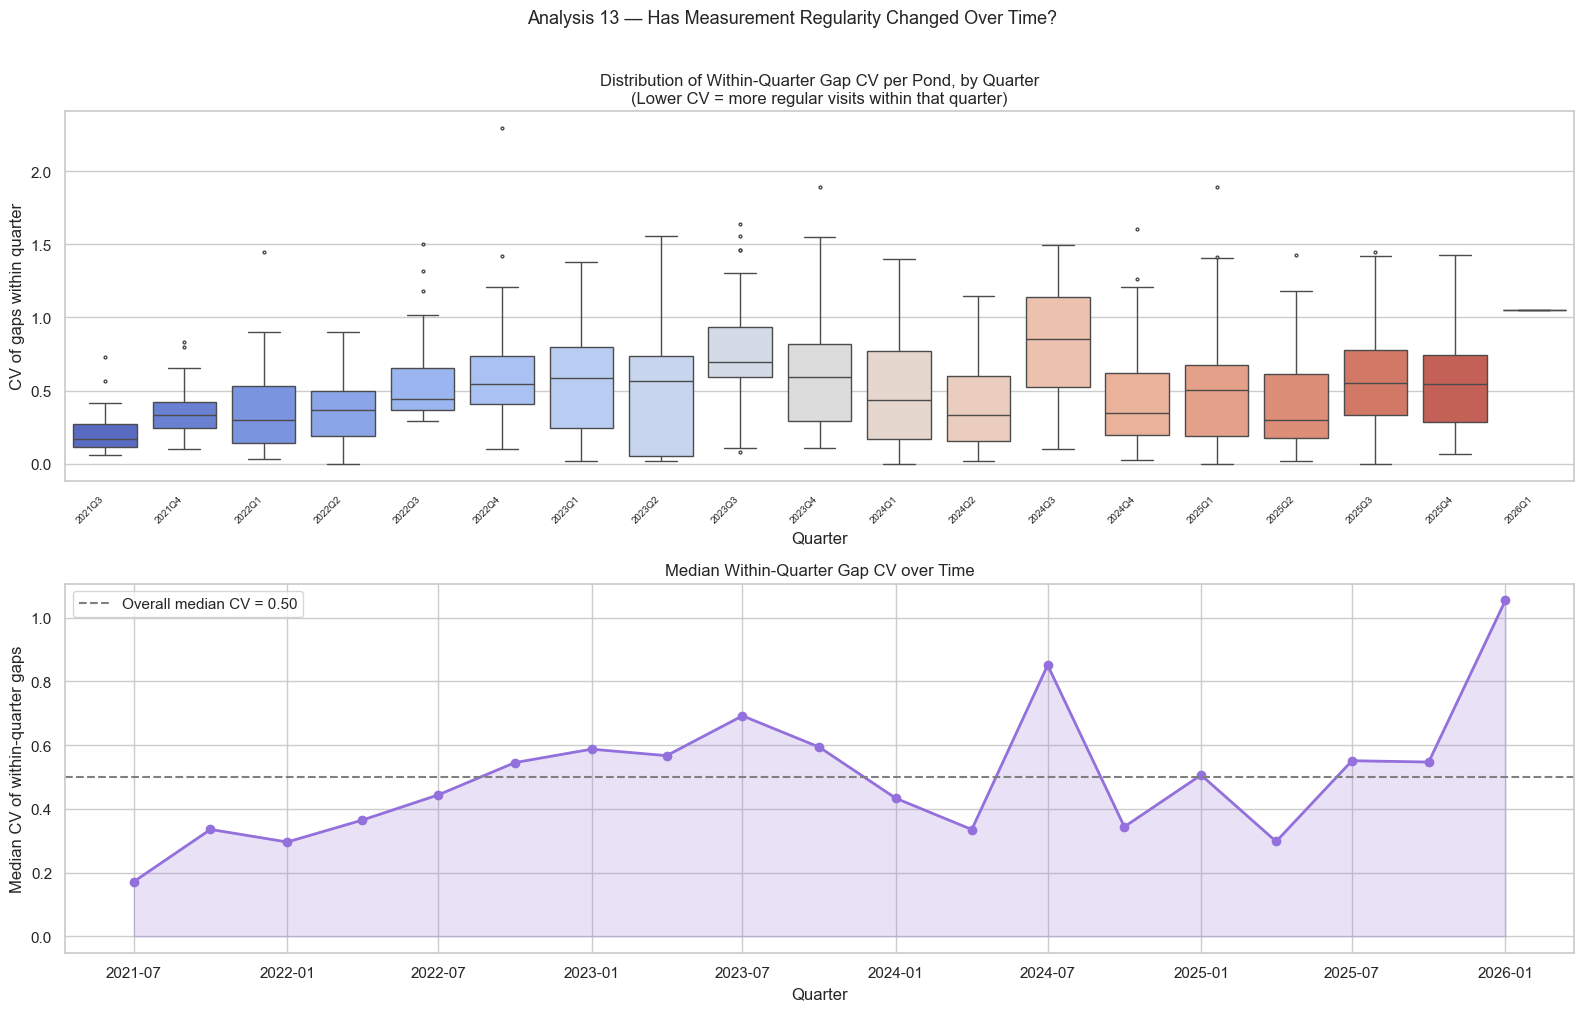

In [20]:
# Per-pond, per quarter — compute CV of gaps within that quarter
# Only include quarters where a pond has ≥3 gaps so CV is meaningful
q_gaps_df = gaps.copy()
q_gaps_df['quarter'] = q_gaps_df['date'].dt.to_period('Q')

def quarter_cv(g):
    if len(g) < 3 or g['gap_days'].mean() == 0:
        return np.nan
    return g['gap_days'].std() / g['gap_days'].mean()

q_reg = (q_gaps_df.groupby(['quarter', 'pond_id'])
         .apply(quarter_cv, include_groups=False)
         .reset_index(name='q_cv'))
q_reg = q_reg.dropna(subset=['q_cv'])
q_reg['q_label'] = q_reg['quarter'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ── Box plot per quarter ──────────────────────────────────────────────────────
ax = axes[0]
order = sorted(q_reg['q_label'].unique())
sns.boxplot(data=q_reg, x='q_label', y='q_cv', order=order, hue='q_label',
            palette='coolwarm', ax=ax, flierprops=dict(markersize=2), legend=False)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_title('Distribution of Within-Quarter Gap CV per Pond, by Quarter\n'
             '(Lower CV = more regular visits within that quarter)')
ax.set_xlabel('Quarter')
ax.set_ylabel('CV of gaps within quarter')

# ── Median CV trend per quarter ───────────────────────────────────────────────
ax = axes[1]
median_q_cv = q_reg.groupby('quarter')['q_cv'].median().reset_index()
median_q_cv['q_dt'] = median_q_cv['quarter'].dt.to_timestamp()
ax.plot(median_q_cv['q_dt'], median_q_cv['q_cv'], marker='o',
        color='mediumpurple', linewidth=2)
ax.fill_between(median_q_cv['q_dt'], median_q_cv['q_cv'], alpha=0.2, color='mediumpurple')
ax.set_title('Median Within-Quarter Gap CV over Time')
ax.set_xlabel('Quarter')
ax.set_ylabel('Median CV of within-quarter gaps')
ax.axhline(median_q_cv['q_cv'].mean(), color='grey', linestyle='--',
           label=f'Overall median CV = {median_q_cv["q_cv"].mean():.2f}')
ax.legend()

plt.suptitle('Analysis 13 — Has Measurement Regularity Changed Over Time?', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Analysis 14 — Cumulative Observations for Top Ponds Over Time

For the 10 most-frequently-measured ponds, how do observations accumulate over the programme timeline?  
Differences in slope reveal periods of more/less intensive monitoring for individual ponds.

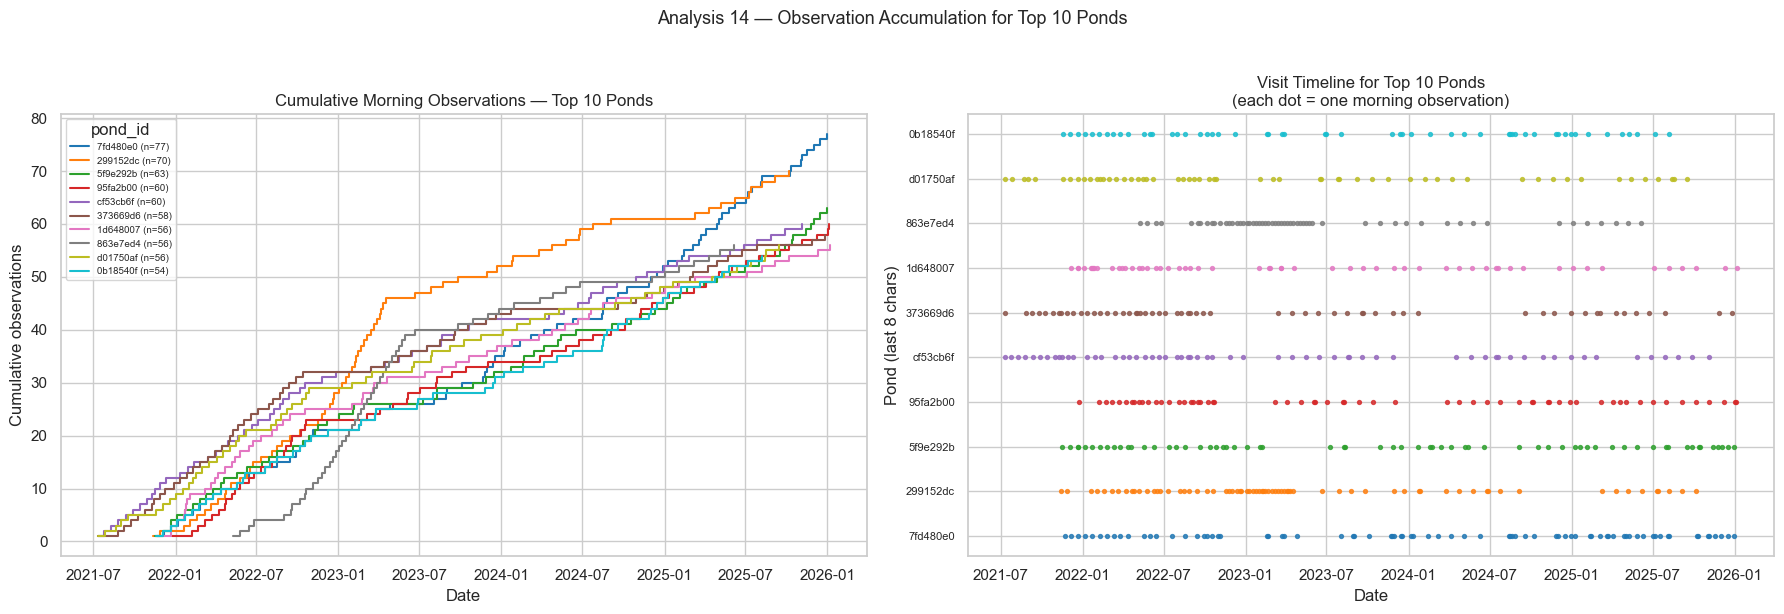

In [21]:
top10_ids = pond_summary.nlargest(10, 'n_obs')['pond_id'].tolist()
top10_data = morning[morning['pond_id'].isin(top10_ids)].sort_values('date')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors_top = sns.color_palette('tab10', n_colors=10)

# ── Cumulative observations ────────────────────────────────────────────────────
ax = axes[0]
for i, pid in enumerate(top10_ids):
    sub = top10_data[top10_data['pond_id'] == pid].sort_values('date')
    sub = sub.assign(cum_obs=range(1, len(sub) + 1))
    label = f"{pid[-8:]} (n={len(sub)})"
    ax.step(sub['date'], sub['cum_obs'], where='post', color=colors_top[i],
            linewidth=1.5, label=label)
ax.legend(fontsize=7, title='pond_id', loc='upper left')
ax.set_title('Cumulative Morning Observations — Top 10 Ponds')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative observations')

# ── Gap timeline (scatter of each visit) ─────────────────────────────────────
ax = axes[1]
for i, pid in enumerate(top10_ids):
    sub = top10_data[top10_data['pond_id'] == pid]
    ax.scatter(sub['date'], [i] * len(sub), color=colors_top[i], s=8, alpha=0.8)
ax.set_yticks(range(10))
ax.set_yticklabels([p[-8:] for p in top10_ids], fontsize=8)
ax.set_title('Visit Timeline for Top 10 Ponds\n(each dot = one morning observation)')
ax.set_xlabel('Date')
ax.set_ylabel('Pond (last 8 chars)')

plt.suptitle('Analysis 14 — Observation Accumulation for Top 10 Ponds', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Analysis 15 — Month-over-Month Pond Retention

What fraction of ponds measured in a given month are also measured in the *following* month?  
This is a "retention rate" showing how consistently the same ponds are revisited month-to-month.

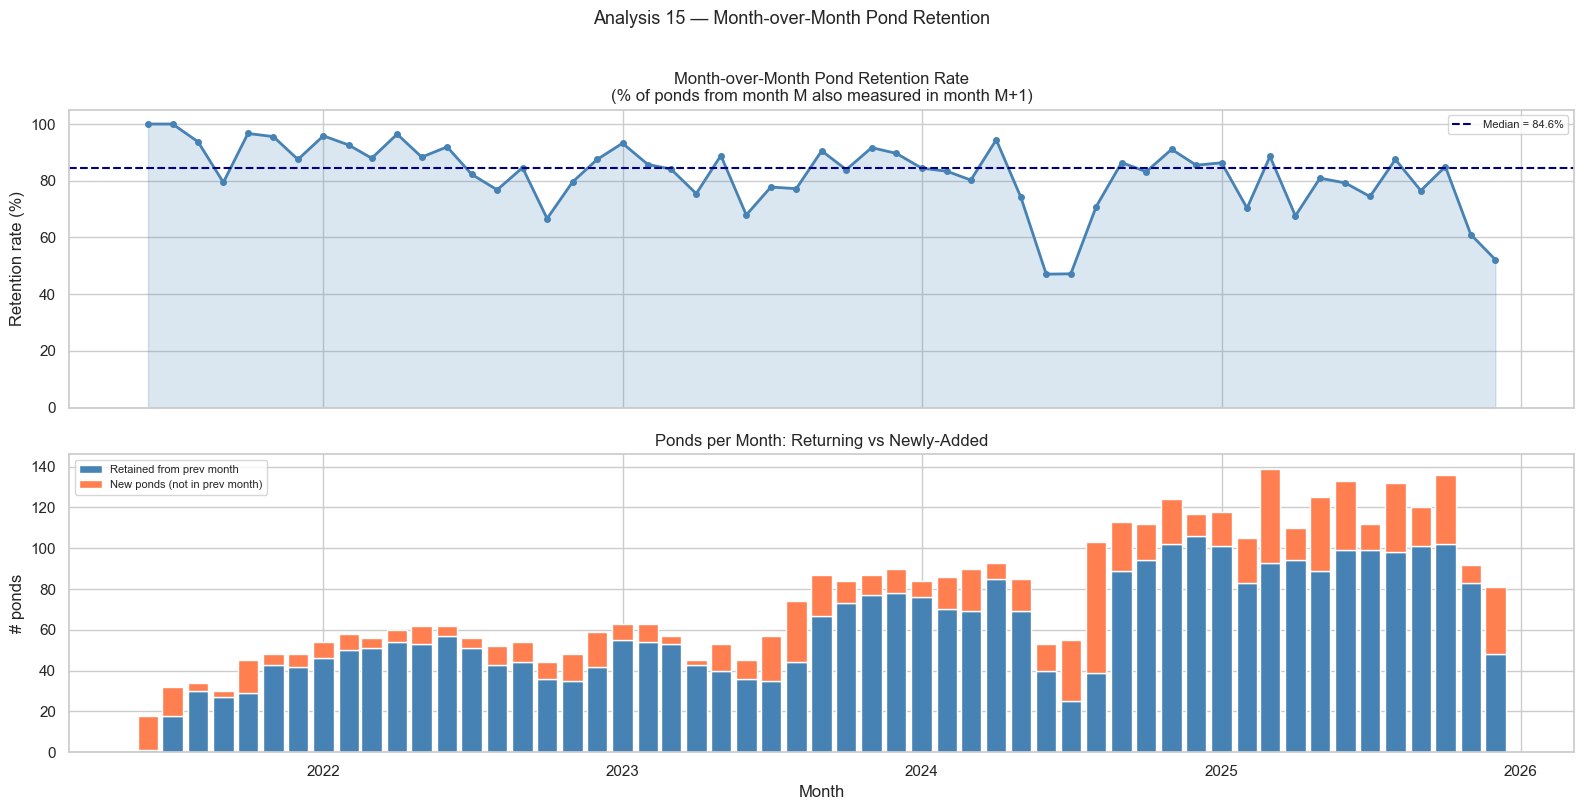

Median monthly retention rate: 84.6%
Min retention rate : 47.1% in 2024-06
Max retention rate : 100.0% in 2021-06


In [22]:
# ponds observed each month
month_ponds = morning.groupby('month')['pond_id'].apply(set)
sorted_months = sorted(month_ponds.index)

retention_rows = []
for i in range(len(sorted_months) - 1):
    m0, m1 = sorted_months[i], sorted_months[i + 1]
    s0, s1 = month_ponds[m0], month_ponds[m1]
    # only consider consecutive calendar months (skip gaps)
    if (m1 - m0).n == 1:
        retained = len(s0 & s1)
        new_in_m1 = len(s1 - s0)
        retention_rows.append({
            'month': m0,
            'month_dt': m0.to_timestamp(),
            'n_ponds_this': len(s0),
            'n_retained_next': retained,
            'n_new_next': new_in_m1,
            'retention_rate': retained / len(s0) if s0 else np.nan,
        })

ret_df = pd.DataFrame(retention_rows)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# ── Retention rate line ───────────────────────────────────────────────────────
ax = axes[0]
ax.plot(ret_df['month_dt'], ret_df['retention_rate'] * 100,
        color='steelblue', linewidth=2, marker='o', markersize=4)
ax.fill_between(ret_df['month_dt'], ret_df['retention_rate'] * 100, alpha=0.2, color='steelblue')
ax.axhline(ret_df['retention_rate'].median() * 100, color='navy', linestyle='--',
           label=f"Median = {ret_df['retention_rate'].median()*100:.1f}%")
ax.set_ylim(0, 105)
ax.set_title('Month-over-Month Pond Retention Rate\n'
             '(% of ponds from month M also measured in month M+1)')
ax.set_ylabel('Retention rate (%)')
ax.legend(fontsize=8)

# ── Stacked bar: retained vs new in next month ────────────────────────────────
ax = axes[1]
ax.bar(ret_df['month_dt'], ret_df['n_retained_next'], width=25,
       color='steelblue', label='Retained from prev month')
ax.bar(ret_df['month_dt'], ret_df['n_new_next'], width=25,
       bottom=ret_df['n_retained_next'], color='coral', label='New ponds (not in prev month)')
ax.set_title('Ponds per Month: Returning vs Newly-Added')
ax.set_ylabel('# ponds')
ax.set_xlabel('Month')
ax.legend(fontsize=8)

plt.suptitle('Analysis 15 — Month-over-Month Pond Retention', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"Median monthly retention rate: {ret_df['retention_rate'].median()*100:.1f}%")
print(f"Min retention rate : {ret_df['retention_rate'].min()*100:.1f}% "
      f"in {ret_df.loc[ret_df.retention_rate.idxmin(), 'month']}")
print(f"Max retention rate : {ret_df['retention_rate'].max()*100:.1f}% "
      f"in {ret_df.loc[ret_df.retention_rate.idxmax(), 'month']}")